<div align="center">

# 04 — Ablasi Negative Anchor: Training 4-Kelas

Notebook ini mereplikasi eksperimen `03_2` dengan menghapus kelas pengecoh (manhole & patchy_road).  
Tujuan: menguji apakah negative anchor class berkontribusi pada presisi deteksi Pothole.  
Dua model dijalankan: **YOLOv8n** (baseline) dan **YOLO-RD** (model terbaik 03_2).

</div>

In [ ]:
# # Jalankan sekali jika environment belum lengkap.
# # Setelah install selesai, restart kernel agar import library bersih.
# import subprocess, sys
# pkgs = [
#     "ultralytics>=8.3.0",
#     "opencv-python-headless",
#     "matplotlib",
#     "seaborn",
#     "pandas",
#     "numpy",
# ]
# subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *pkgs])
# print("Install selesai — restart kernel sekarang.")

In [1]:
import torch
print(f"torch version     : {torch.__version__}")
print(f"torch cuda build  : {torch.version.cuda}")
print(f"CUDA available    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU               : {torch.cuda.get_device_name(0)}")

torch version     : 2.5.1+cu121
torch cuda build  : 12.1
CUDA available    : True
GPU               : NVIDIA GeForce RTX 4070 SUPER


## ***Konfigurasi Global***

---

Satu cell ini berisi seluruh konstanta eksperimen. Ubah di sini, bukan di cell lain.

In [ ]:
from pathlib import Path

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42

# ── Smoke test flag ──────────────────────────────────────────────────────────
# True  → 2 epoch, cepat untuk verifikasi pipeline
# False → 300 epoch, eksperimen final
SMOKE_TEST = False

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT_CANDIDATES = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path("D:/01_Akademik/TA-Project"),
]
REPO_ROOT = next(
    (p for p in ROOT_CANDIDATES if (p / "data").exists()),
    Path.cwd().resolve(),
)
# Dataset 6-kelas asli (hanya untuk referensi gambar via symlink)
SRC_DATASET_DIR = (
    REPO_ROOT
    / "data/NRDD-2024/RDD_Split_Final_china_japan_india_6_classes"
    / "RDD_Split_Final_china_japan_india_6_classes"
)
# Dataset 4-kelas — label sudah difilter (ID 4 & 5 dihapus), gambar symlink ke asli
DATASET_DIR = REPO_ROOT / "data/NRDD-2024/RDD_4class"
OUTPUT_DIR = REPO_ROOT / "runs/rdd_4class_local"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Training hyperparameters ─────────────────────────────────────────────────
EPOCHS      = 2 if SMOKE_TEST else 300
PATIENCE    = 10 if SMOKE_TEST else 40
IMGSZ       = 640

# ── Focal loss ───────────────────────────────────────────────────────────────
FOCAL_GAMMA = 1.5

# ── Augmentasi ───────────────────────────────────────────────────────────────
MOSAIC       = 1.0
MIXUP        = 0.05
FLIPLR       = 0.5
TRANSLATE    = 0.10
SCALE        = 0.50
DEGREES      = 0.0   # Tidak menggunakan rotasi (arahan metodologi/dospem)
CLOSE_MOSAIC = 10

# ── Evaluasi ─────────────────────────────────────────────────────────────────
EVAL_CONF    = 0.001
EVAL_IOU     = 0.60
PRED_CONF    = 0.25
PRED_IOU     = 0.60

# ── Kelas dataset (4 kelas — tanpa manhole & patchy_road) ────────────────────
CLASS_NAMES = [
    "Longitudinal_Crack",
    "Transverse_Crack",
    "Alligator_Crack",
    "Pothole",
]

# ── Daftar model ─────────────────────────────────────────────────────────────
# kind:
#   "pretrained"  → spec adalah nama file .pt di code/ (atau nama yg di-download Ultralytics)
#   "yaml_custom" → spec adalah path yaml relatif terhadap REPO_ROOT
# Hanya yolov8n dan yolo_rd yang diaktifkan untuk perbandingan 6-class vs 4-class.
# Tiga model lain di-comment agar mudah diaktifkan kembali jika diperlukan.
MODELS = [
    # {"name": "yolov8n_4cls_class_weights",   "spec": "yolov8n.pt",               "kind": "pretrained",  "batch": 16, "amp": True},
    # {"name": "yolov12n_4cls_class_weights",  "spec": "yolo12n.pt",               "kind": "pretrained",  "batch": 16, "amp": True},
    {"name": "yolov26n_4cls_class_weights",  "spec": "yolo26n.pt",               "kind": "pretrained",  "batch": 16, "amp": True},
    # {"name": "yolov8_pd_4cls_class_weights", "spec": "code/models/yolov8-pd.yaml", "kind": "yaml_custom", "batch": 16, "amp": False},
    # {"name": "yolo_rd_4cls_class_weights",   "spec": "code/models/yolo-rd.yaml",  "kind": "yaml_custom", "batch": 16,  "amp": False},
]

# ── Verifikasi path ──────────────────────────────────────────────────────────
print(f"Repo root   : {REPO_ROOT}")
print(f"Dataset dir : {DATASET_DIR}")
print(f"Output dir  : {OUTPUT_DIR}")
print(f"Smoke test  : {SMOKE_TEST}  →  epochs={EPOCHS}, patience={PATIENCE}")
assert DATASET_DIR.exists(), f"Dataset tidak ditemukan: {DATASET_DIR}"

Repo root   : D:\Faaris\Project-TA\road-damage-detection-ta
Dataset dir : D:\Faaris\Project-TA\road-damage-detection-ta\data\NRDD-2024\RDD_4class
Output dir  : D:\Faaris\Project-TA\road-damage-detection-ta\runs\rdd_4class_local
Smoke test  : False  →  epochs=300, patience=40


## ***Imports dan Setup Awal***

---

In [5]:
import json
import os
import random
import sys
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from IPython.display import Image, display

# Seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU / CPU
print(f"Torch version       : {torch.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device count   : {torch.cuda.device_count()}")
    print(f"Current GPU         : {torch.cuda.get_device_name(0)}")
    DEVICE = 0
    BATCH  = 16   # default; tiap model bisa override via MODELS[i]["batch"]
else:
    print("Training akan berjalan di CPU. Untuk 300 epoch, sangat disarankan memakai GPU.")
    DEVICE = "cpu"
    BATCH  = 4

# Windows notebook lebih stabil dengan workers=0
WORKERS = 0 if os.name == "nt" else 4
print(f"Device untuk YOLO   : {DEVICE}")
print(f"Batch default       : {BATCH}")
print(f"Dataloader workers  : {WORKERS}")

Torch version       : 2.5.1+cu121
CUDA available      : True
CUDA device count   : 1
Current GPU         : NVIDIA GeForce RTX 4070 SUPER
Device untuk YOLO   : 0
Batch default       : 16
Dataloader workers  : 0


## ***Persiapan Dataset 4-Kelas***

---

Dataset `RDD_4class` dibuat oleh script `code/prepare_4class_dataset.py`.
**Jalankan script ini satu kali sebelum notebook ini dieksekusi**, terutama setelah `git pull` di mesin baru.

```bash
python code/prepare_4class_dataset.py
```

Yang dilakukan script:
- Label file difilter — baris dengan class ID 4 (manhole) dan 5 (patchy_road) dihapus.
- Gambar di-symlink ke dataset asli di Linux/Mac (tidak ada copy fisik).
- Di Windows: dicoba symlink dulu, fallback ke copy otomatis jika Developer Mode tidak aktif.
- File `data.yaml` dibuat di folder `data/NRDD-2024/RDD_4class/`.

Cell berikut memverifikasi dataset sudah ada sebelum melanjutkan.

In [6]:
import yaml

# ── Verifikasi dataset 4-kelas sudah disiapkan ───────────────────────────────
_missing = []
for _split in ["train", "val", "test"]:
    _img = DATASET_DIR / _split / "images"
    _lbl = DATASET_DIR / _split / "labels"
    if not _img.exists(): _missing.append(str(_img))
    if not _lbl.exists(): _missing.append(str(_lbl))

if _missing:
    raise FileNotFoundError(
        "Dataset 4-kelas belum disiapkan. Jalankan dulu:\n"
        "  python code/prepare_4class_dataset.py\n\n"
        "Folder tidak ditemukan:\n" + "\n".join(f"  {p}" for p in _missing)
    )

print("Dataset 4-kelas terverifikasi:")
for _split in ["train", "val", "test"]:
    _n_img = len(list((DATASET_DIR / _split / "images").iterdir()))
    _n_lbl = len(list((DATASET_DIR / _split / "labels").glob("*.txt")))
    print(f"  {_split:5s}: {_n_img} gambar, {_n_lbl} label files")

# ── Buat rdd4_local.yaml di OUTPUT_DIR untuk logging ─────────────────────────
original_yaml = DATASET_DIR / "data.yaml"
with original_yaml.open("r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

data_cfg["path"]  = str(DATASET_DIR.resolve()).replace("\\", "/")
data_cfg["train"] = "train/images"
data_cfg["val"]   = "val/images"
data_cfg["test"]  = "test/images"
data_cfg["nc"]    = len(CLASS_NAMES)
data_cfg["names"] = CLASS_NAMES

local_yaml = OUTPUT_DIR / "rdd4_local.yaml"
with local_yaml.open("w", encoding="utf-8") as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False, allow_unicode=False)

print(f"\nYAML tersimpan: {local_yaml}")
print(local_yaml.read_text(encoding="utf-8"))

Dataset 4-kelas terverifikasi:
  train: 6777 gambar, 6777 label files
  val  : 1898 gambar, 1898 label files
  test : 995 gambar, 995 label files

YAML tersimpan: D:\Faaris\Project-TA\road-damage-detection-ta\runs\rdd_4class_local\rdd4_local.yaml
path: D:/Faaris/Project-TA/road-damage-detection-ta/data/NRDD-2024/RDD_4class
train: train/images
val: val/images
test: test/images
nc: 4
names:
- Longitudinal_Crack
- Transverse_Crack
- Alligator_Crack
- Pothole



## ***Audit Dataset***

---

Audit jumlah gambar, label, objek, missing label, dan extra label sebelum training.
Label file sudah bersih (ID 4 & 5 telah dihapus di preprocessing). Audit ini memverifikasi hasilnya.
File `classes.txt` di folder labels diabaikan.

In [7]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def list_images(split: str):
    image_dir = DATASET_DIR / split / "images"
    return sorted([p for p in image_dir.iterdir() if p.suffix.lower() in IMG_EXTS])


def list_label_files(split: str):
    label_dir = DATASET_DIR / split / "labels"
    return sorted([p for p in label_dir.glob("*.txt") if p.name.lower() != "classes.txt"])


def read_yolo_labels(label_path):
    rows = []
    for line_no, line in enumerate(
        label_path.read_text(encoding="utf-8", errors="ignore").splitlines(), start=1
    ):
        parts = line.strip().split()
        if not parts:
            continue
        if len(parts) != 5:
            rows.append({"file": label_path.name, "line": line_no, "error": "not_5_columns", "raw": line})
            continue
        try:
            class_id = int(parts[0])
            x, y, w, h = map(float, parts[1:])
        except ValueError:
            rows.append({"file": label_path.name, "line": line_no, "error": "parse_error", "raw": line})
            continue
        rows.append({"file": label_path.name, "line": line_no, "class_id": class_id,
                     "x": x, "y": y, "w": w, "h": h})
    return rows


summary_rows = []
label_rows   = []
invalid_rows = []

for split in ["train", "val", "test"]:
    images = list_images(split)
    labels = list_label_files(split)
    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    split_counter = Counter({i: 0 for i in range(len(CLASS_NAMES))})
    split_objects = 0

    for lp in labels:
        for row in read_yolo_labels(lp):
            if "error" in row:
                invalid_rows.append({"split": split, **row})
                continue
            class_id = row["class_id"]
            # Hanya hitung kelas 0–3 (4-class); abaikan ID 4 & 5
            if class_id < 0 or class_id >= len(CLASS_NAMES):
                continue
            if not all(0.0 <= row[k] <= 1.0 for k in ["x", "y", "w", "h"]):
                invalid_rows.append({"split": split, "file": row["file"], "error": "bbox_out_of_0_1_range", **row})
                continue
            split_counter[class_id] += 1
            split_objects += 1
            label_rows.append({"split": split, "class_id": class_id, "class_name": CLASS_NAMES[class_id], **row})

    summary_rows.append({
        "split": split,
        "images": len(images),
        "labels": len(labels),
        "objects": split_objects,
        "missing_label_files": len(image_stems - label_stems),
        "extra_label_files": len(label_stems - image_stems),
    })

summary_df  = pd.DataFrame(summary_rows)
labels_df   = pd.DataFrame(label_rows)
invalid_df  = pd.DataFrame(invalid_rows)

class_df = (
    labels_df.groupby(["split", "class_id", "class_name"])
    .size().rename("objects").reset_index()
)
class_pivot = class_df.pivot_table(
    index=["class_id", "class_name"], columns="split", values="objects", fill_value=0
).reset_index()
for col in ["train", "val", "test"]:
    if col not in class_pivot.columns:
        class_pivot[col] = 0
class_pivot["total"]   = class_pivot[["train", "val", "test"]].sum(axis=1)
class_pivot["percent"] = class_pivot["total"] / class_pivot["total"].sum() * 100

print("Summary split:")
display(summary_df)
print("Distribusi kelas (4 kelas aktif):")
display(class_pivot[["class_id", "class_name", "train", "val", "test", "total", "percent"]])

class_pivot.to_csv(OUTPUT_DIR / "dataset_class_distribution_4cls.csv", index=False)
summary_df.to_csv(OUTPUT_DIR / "dataset_split_summary_4cls.csv", index=False)

Summary split:


,split,images,labels,objects,missing_label_files,extra_label_files
0,train,6777,6777,14351,0,0
1,val,1898,1898,3996,0,0
2,test,995,995,2035,0,0


Distribusi kelas (4 kelas aktif):


split,class_id,class_name,train,val,test,total,percent
0,0,Longitudinal_Crack,4555.0,1257.0,635.0,6447.0,31.630851
1,1,Transverse_Crack,3219.0,897.0,446.0,4562.0,22.382494
2,2,Alligator_Crack,4385.0,1245.0,642.0,6272.0,30.772250
3,3,Pothole,2192.0,597.0,312.0,3101.0,15.214405


### ***Visualisasi Distribusi Kelas***

C:\Users\User\AppData\Local\Temp\ipykernel_2252\2806052846.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(class_pivot["class_name"], rotation=25, ha="right")


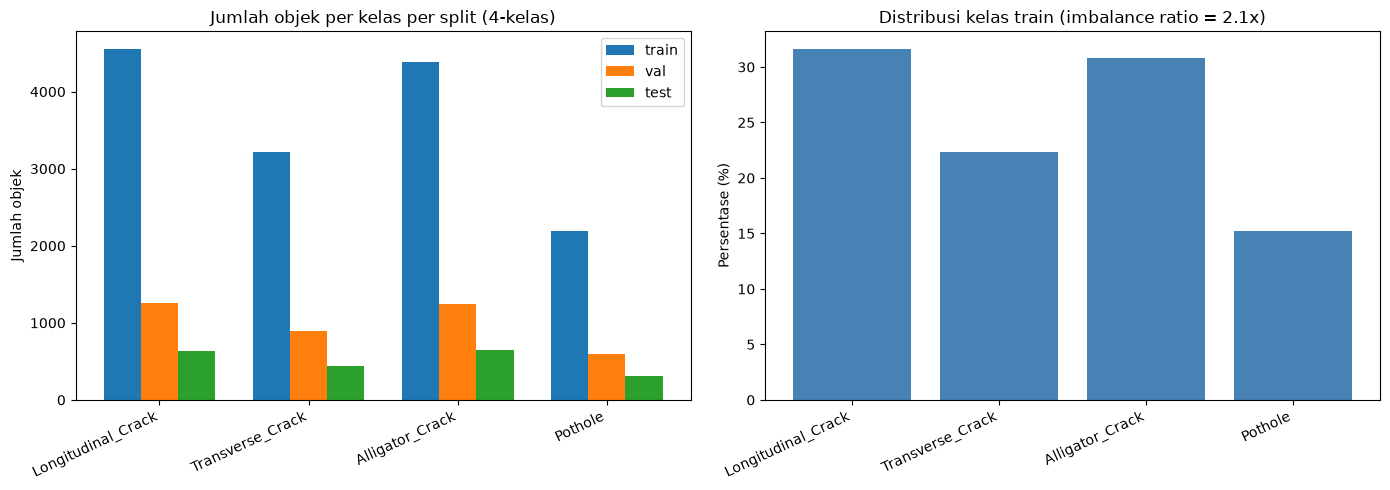

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

splits_plot = ["train", "val", "test"]
x = np.arange(len(CLASS_NAMES))
width = 0.25
for i, split in enumerate(splits_plot):
    axes[0].bar(x + i * width, class_pivot[split], width, label=split)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(class_pivot["class_name"], rotation=25, ha="right")
axes[0].set_title("Jumlah objek per kelas per split (4-kelas)")
axes[0].set_ylabel("Jumlah objek")
axes[0].legend()

max_count = class_pivot["train"].max()
min_count = class_pivot["train"].replace(0, np.nan).min()
imbalance_ratio = max_count / min_count if min_count and min_count > 0 else float("nan")
axes[1].bar(class_pivot["class_name"], class_pivot["percent"], color="steelblue")
axes[1].set_xticklabels(class_pivot["class_name"], rotation=25, ha="right")
axes[1].set_title(f"Distribusi kelas train (imbalance ratio = {imbalance_ratio:.1f}x)")
axes[1].set_ylabel("Persentase (%)")

plt.tight_layout()
plt.show()

## ***Training (Loop)***

---

Loop melakukan iterasi pada `MODELS`. Setiap model:
1. Disiapkan dengan Class-Balanced weighting (Cui et al., CVPR 2019) via patch `DetectionModel.init_criterion`.
2. Untuk `kind == "yaml_custom"`: load arsitektur dari YAML, lalu transfer bobot COCO via `.load("yolov8n.pt")`.
3. Untuk `kind == "pretrained"`: `YOLO(spec)` biasa.
4. Output tersimpan di `runs/rdd_4class_local/experiments/<run_name>/`.

In [9]:
CUSTOM_DIR = REPO_ROOT / "code/models"

HAS_CUSTOM = any(m["kind"] == "yaml_custom" for m in MODELS)
if HAS_CUSTOM:
    sys.path.insert(0, str(CUSTOM_DIR))
    from custom_modules import patch_ultralytics
    patch_ultralytics()
    print("patch_ultralytics() dipanggil — modul custom terdaftar.")


import gc
import yaml
import numpy as np
from pathlib import Path
from collections import Counter
from ultralytics import YOLO
from ultralytics.nn.tasks import DetectionModel
from ultralytics.utils.loss import v8DetectionLoss, E2ELoss


def count_class_instances(data_yaml_path, split="train"):
    """Scan file label YOLO-format (.txt) pada split tertentu, hitung jumlah
    instance per kelas (list sepanjang nc, terurut sesuai data.yaml)."""
    data_yaml_path = Path(data_yaml_path)
    with open(data_yaml_path) as f:
        cfg = yaml.safe_load(f)
    base = Path(cfg.get("path", data_yaml_path.parent))
    if not base.is_absolute():
        base = data_yaml_path.parent / base
    split_val = cfg[split]
    img_dirs = [split_val] if isinstance(split_val, str) else list(split_val)
    nc = cfg["nc"]
    counts = Counter({i: 0 for i in range(nc)})
    for img_dir in img_dirs:
        label_dir_path = Path(str(base / img_dir).replace("images", "labels"))
        for txt_file in label_dir_path.rglob("*.txt"):
            if txt_file.name.lower() == "classes.txt":
                continue
            with open(txt_file) as f:
                for line in f:
                    line = line.strip()
                    if line:
                        cid = int(line.split()[0])
                        if cid in counts:   # hanya hitung ID dalam nc=4
                            counts[cid] += 1
    return [counts[i] for i in range(nc)]


def effective_number_weights(counts, beta=0.999):
    """Class-Balanced weighting via Effective Number of Samples.
    Cui, Y., Jia, M., Lin, T-Y., Song, Y., & Belongie, S. (2019).
    "Class-Balanced Loss Based on Effective Number of Samples." CVPR 2019.
    https://arxiv.org/abs/1901.05555
    """
    counts_arr = np.clip(np.array(counts, dtype=np.float64), 1, None)
    effective_num = 1.0 - np.power(beta, counts_arr)
    weights = (1.0 - beta) / effective_num
    weights = weights / weights.sum() * len(counts_arr)
    return torch.tensor(weights, dtype=torch.float32)


print("Menghitung distribusi kelas dari dataset training...")
CLASS_COUNTS = count_class_instances(local_yaml, split="train")
CLASS_WEIGHTS = effective_number_weights(CLASS_COUNTS, beta=0.999)
print(f"Jumlah per kelas : {CLASS_COUNTS}")
print(f"Class weights    : {[round(w, 3) for w in CLASS_WEIGHTS.tolist()]}")


def _init_criterion_with_class_weights(self):
    """Patch di level CLASS DetectionModel — berlaku otomatis untuk semua
    model (YOLOv8n, YOLO-RD) karena Trainer membangun ulang model dari nol
    di dalam `.train()`."""
    if getattr(self, "class_weights", None) is None:
        self.class_weights = CLASS_WEIGHTS.to(next(self.parameters()).device)
    if getattr(self, "end2end", False):
        return E2ELoss(self)
    return v8DetectionLoss(self)

DetectionModel.init_criterion = _init_criterion_with_class_weights

# Verifikasi class_weights aktif
_dummy = YOLO("yolov8n.pt")
_dummy.model.train()
_crit = _dummy.model.init_criterion()
assert torch.allclose(_crit.class_weights.cpu(), CLASS_WEIGHTS), "class_weights tidak aktif!"
print(f"Class-balanced weighting terverifikasi aktif (beta=0.999, sumber: Cui et al. CVPR 2019)")
del _dummy, _crit

patch_ultralytics() dipanggil — modul custom terdaftar.
Menghitung distribusi kelas dari dataset training...
Jumlah per kelas : [4555, 3219, 4385, 2192]
Class weights    : [0.965, 0.994, 0.967, 1.074]
Class-balanced weighting terverifikasi aktif (beta=0.999, sumber: Cui et al. CVPR 2019)


In [15]:
# Utility VRAM flush — dijalankan sekali sebelum loop training jika diperlukan.
# Jika cell sebelumnya sempat load model dan gagal, jalankan cell ini terlebih dahulu.
try:
    del model
except NameError:
    pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    mem_free = torch.cuda.mem_get_info()[0] / 1024**3
    print(f"GPU VRAM bebas: {mem_free:.2f} GB")

GPU VRAM bebas: 10.35 GB


In [16]:
MODELS = [
    # {"name": "yolov8n_4cls_class_weights",   "spec": "yolov8n.pt",               "kind": "pretrained",  "batch": 16, "amp": True},
    # {"name": "yolov12n_4cls_class_weights",  "spec": "yolo12n.pt",               "kind": "pretrained",  "batch": 16, "amp": True},
    {"name": "yolov26n_4cls_class_weights",  "spec": "yolo26n.pt",               "kind": "pretrained",  "batch": 16, "amp": True},
    # {"name": "yolov8_pd_4cls_class_weights", "spec": "code/models/yolov8-pd.yaml", "kind": "yaml_custom", "batch": 16, "amp": False},
    # {"name": "yolo_rd_4cls_class_weights",   "spec": "code/models/yolo-rd.yaml",  "kind": "yaml_custom", "batch": 16,  "amp": False},
]

In [17]:
PROJECT_DIR  = OUTPUT_DIR / "experiments"
trained_runs = []  # daftar (model_name, run_name) untuk cell evaluasi

for m in MODELS:
    run_name = f"{m['name']}_smoke" if SMOKE_TEST else m["name"]
    print(f"\n{'='*60}")
    print(f"Training: {run_name}")
    print(f"{'='*60}")

    if m["kind"] == "yaml_custom":
        spec_path = REPO_ROOT / m["spec"]
        model = YOLO(str(spec_path), task="detect")
        model.load(str(REPO_ROOT / "code/yolov8n.pt"))
    else:
        # pretrained: coba resolve dari code/ dulu, fallback ke auto-download
        spec_path_local = REPO_ROOT / "code" / m["spec"]
        spec = str(spec_path_local) if spec_path_local.exists() else m["spec"]
        model = YOLO(spec)

    batch_size = m.get("batch", BATCH)
    amp_flag   = m.get("amp", True)

    model.train(
        data=str(local_yaml),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=batch_size,
        device=DEVICE,
        workers=WORKERS,
        project=str(PROJECT_DIR),
        name=run_name,
        exist_ok=True,
        seed=SEED,
        deterministic=True,
        optimizer="auto",
        patience=PATIENCE,
        cache=False,
        amp=amp_flag,
        cos_lr=True,
        plots=True,
        save=True,
        save_period=25,
        close_mosaic=CLOSE_MOSAIC,
        mosaic=MOSAIC,
        mixup=MIXUP,
        fliplr=FLIPLR,
        translate=TRANSLATE,
        scale=SCALE,
        degrees=DEGREES,
    )

    trained_runs.append((m["name"], run_name))
    print(f"Selesai: {run_name}")

    # Bebaskan VRAM sebelum model berikutnya
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        mem_free = torch.cuda.mem_get_info()[0] / 1024**3
        print(f"  GPU VRAM bebas setelah cleanup: {mem_free:.2f} GB")

print("\nSemua model selesai ditraining:", trained_runs)


Training: yolov26n_4cls_class_weights
New https://pypi.org/project/ultralytics/8.4.115 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.108  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 12282MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=D:\Faaris\Project-TA\road-damage-detection-ta\runs\rdd_4class_local\rdd4_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7

## ***Evaluasi per Model***

---

Evaluasi val dan test untuk setiap model. Output disimpan di `runs/rdd_4class_local/evaluation/` dengan prefix nama model.

In [18]:
# PROJECT_DIR  = OUTPUT_DIR / "experiments"
# # Isi manual setelah restart kernel, sesuaikan nama run
# trained_runs = [
#     ("yolov8n_4cls_smoke", "yolov8n_4cls_smoke"),  # atau "yolov8n_4cls_smoke" kalau smoke test
#     ("yolo_rd_4cls_smoke", "yolo_rd_4cls_smoke"),
# ]

In [19]:
# Jika modul custom diperlukan saat load best.pt, patch harus sudah aktif.
if HAS_CUSTOM and "patch_ultralytics" not in dir():
    sys.path.insert(0, str(CUSTOM_DIR))
    from custom_modules import patch_ultralytics
    patch_ultralytics()

EVAL_DIR     = OUTPUT_DIR / "evaluation"
eval_results = {}  # model_name → {"val": metrics, "test": metrics}

for model_name, run_name in trained_runs:
    best_weights = PROJECT_DIR / run_name / "weights/best.pt"
    assert best_weights.exists(), f"best.pt tidak ditemukan: {best_weights}"

    best_model = YOLO(str(best_weights))

    print(f"Evaluasi {model_name} — val")
    val_metrics = best_model.val(
        data=str(local_yaml),
        split="val",
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        workers=WORKERS,
        project=str(EVAL_DIR),
        name=f"{model_name}_val",
        exist_ok=True,
        plots=True,
        save_json=True,
        conf=EVAL_CONF,
        iou=EVAL_IOU,
    )

    print(f"valuasi {model_name} — test")
    test_metrics = best_model.val(
        data=str(local_yaml),
        split="test",
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        workers=WORKERS,
        project=str(EVAL_DIR),
        name=f"{model_name}_test",
        exist_ok=True,
        plots=True,
        save_json=True,
        conf=EVAL_CONF,
        iou=EVAL_IOU,
    )

    eval_results[model_name] = {"val": val_metrics, "test": test_metrics}
    print(f"  val  mAP50: {val_metrics.results_dict.get('metrics/mAP50(B)', float('nan')):.4f}")
    print(f"  test mAP50: {test_metrics.results_dict.get('metrics/mAP50(B)', float('nan')):.4f}")

    # --- CLEAR CACHE SETELAH EVALUASI ---
    del best_model
    import gc
    import torch
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Evaluasi yolov26n_4cls_class_weights — val
Ultralytics 8.4.108  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 12282MiB)
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 682.8323.3 MB/s, size: 75.2 KB)
val: Scanning D:\Faaris\Project-TA\road-damage-detection-ta\data\NRDD-2024\RDD_4class\val\labels.cache... 1898 images, 100 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1898/1898  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 119/119 8.2it/s 14.5s0.1s
                   all       1898       3996      0.674      0.528      0.587      0.303
    Longitudinal_Crack        788       1257      0.703       0.55      0.617      0.357
      Transverse_Crack        532        897      0.625      0.488      0.551       0.27
       Alligator_Crack        960       1245      0.702      0.602      0.655      0.353
               Pothol

### ***Metrik Per Kelas dan F1 Summary***

In [20]:
def per_class_metrics(metrics, class_names):
    rows = []
    box  = metrics.box
    for class_id, class_name in enumerate(class_names):
        try:
            precision, recall, ap50, ap5095 = box.class_result(class_id)
        except Exception:
            precision, recall, ap50, ap5095 = np.nan, np.nan, np.nan, np.nan
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        rows.append({
            "class_id":   class_id,
            "class_name": class_name,
            "precision":  float(precision),
            "recall":     float(recall),
            "f1":         float(f1),
            "mAP50":      float(ap50),
            "mAP50-95":   float(ap5095),
        })
    return pd.DataFrame(rows)


def safe_weighted_mean(values, weights):
    values  = np.asarray(values,  dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid   = np.isfinite(values) & np.isfinite(weights)
    if not valid.any() or weights[valid].sum() == 0:
        return float("nan")
    return float(np.average(values[valid], weights=weights[valid]))


for model_name, run_name in trained_runs:
    val_metrics  = eval_results[model_name]["val"]
    test_metrics = eval_results[model_name]["test"]

    val_per_class  = per_class_metrics(val_metrics,  CLASS_NAMES)
    test_per_class = per_class_metrics(test_metrics, CLASS_NAMES)

    val_per_class = val_per_class.merge(
        class_pivot[["class_id", "val"]].rename(columns={"val": "support"}),
        on="class_id", how="left",
    )
    test_per_class = test_per_class.merge(
        class_pivot[["class_id", "test"]].rename(columns={"test": "support"}),
        on="class_id", how="left",
    )

    f1_summary = {
        "val_macro_f1":    float(val_per_class["f1"].mean()),
        "val_weighted_f1": safe_weighted_mean(val_per_class["f1"], val_per_class["support"]),
        "test_macro_f1":   float(test_per_class["f1"].mean()),
        "test_weighted_f1": safe_weighted_mean(test_per_class["f1"], test_per_class["support"]),
    }
    f1_summary_df = pd.DataFrame([f1_summary])

    print(f"\n{'─'*50}")
    print(f"Model: {model_name}")
    print("F1 summary:")
    display(f1_summary_df)
    print("Test per-class metrics:")
    display(test_per_class)

    # Simpan CSV per model
    val_per_class.to_csv(OUTPUT_DIR  / f"{model_name}_val_per_class_metrics.csv",  index=False)
    test_per_class.to_csv(OUTPUT_DIR / f"{model_name}_test_per_class_metrics.csv", index=False)
    f1_summary_df.to_csv(OUTPUT_DIR  / f"{model_name}_f1_summary.csv",             index=False)

    # Simpan summary JSON per model
    speed_total_ms = sum(
        float(v) for k, v in test_metrics.speed.items()
        if k in ["preprocess", "inference", "postprocess"]
    )
    summary = {
        "model":      model_name,
        "run_name":   run_name,
        "weights":    str(PROJECT_DIR / run_name / "weights/best.pt"),
        "data_yaml":  str(local_yaml),
        "nc":         len(CLASS_NAMES),
        "class_names": CLASS_NAMES,
        "imgsz":      IMGSZ,
        "epochs":     EPOCHS,
        "focal_gamma": FOCAL_GAMMA,
        "val_results":  {k: float(v) for k, v in val_metrics.results_dict.items()},
        "test_results": {k: float(v) for k, v in test_metrics.results_dict.items()},
        "f1_summary":   f1_summary,
        "test_speed_ms_per_image": {k: float(v) for k, v in test_metrics.speed.items()},
        "test_fps_estimate": 1000.0 / speed_total_ms if speed_total_ms > 0 else None,
    }
    with (OUTPUT_DIR / f"{model_name}_summary.json").open("w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    print(json.dumps(summary, indent=2))


──────────────────────────────────────────────────
Model: yolov26n_4cls_class_weights
F1 summary:


,val_macro_f1,val_weighted_f1,test_macro_f1,test_weighted_f1
0,0.591584,0.601648,0.595445,0.605763


Test per-class metrics:


,class_id,class_name,precision,recall,f1,mAP50,mAP50-95,support
0,0,Longitudinal_Crack,0.668531,0.588976,0.626237,0.639541,0.373700,635.0
1,1,Transverse_Crack,0.606090,0.493334,0.543930,0.536504,0.262975,446.0
2,2,Alligator_Crack,0.675402,0.626168,0.649854,0.676246,0.374910,642.0
3,3,Pothole,0.666002,0.485730,0.561758,0.562089,0.241910,312.0


{
  "model": "yolov26n_4cls_class_weights",
  "run_name": "yolov26n_4cls_class_weights",
  "weights": "D:\\Faaris\\Project-TA\\road-damage-detection-ta\\runs\\rdd_4class_local\\experiments\\yolov26n_4cls_class_weights\\weights\\best.pt",
  "data_yaml": "D:\\Faaris\\Project-TA\\road-damage-detection-ta\\runs\\rdd_4class_local\\rdd4_local.yaml",
  "nc": 4,
  "class_names": [
    "Longitudinal_Crack",
    "Transverse_Crack",
    "Alligator_Crack",
    "Pothole"
  ],
  "imgsz": 640,
  "epochs": 300,
  "focal_gamma": 1.5,
  "val_results": {
    "metrics/precision(B)": 0.673520425868759,
    "metrics/recall(B)": 0.5284147875683634,
    "metrics/mAP50(B)": 0.5866291324082877,
    "metrics/mAP50-95(B)": 0.3028626383815265,
    "fitness": 0.3028626383815265
  },
  "test_results": {
    "metrics/precision(B)": 0.6540062892943107,
    "metrics/recall(B)": 0.5485520058435046,
    "metrics/mAP50(B)": 0.6035950186099297,
    "metrics/mAP50-95(B)": 0.3133736343950714,
    "fitness": 0.313373634395071

### ***Confusion Matrix / PR Curve / F1 Curve per Model***


──────────────────────────────────────────────────
Model: yolov8n_4cls_class_weights
  val — confusion_matrix.png


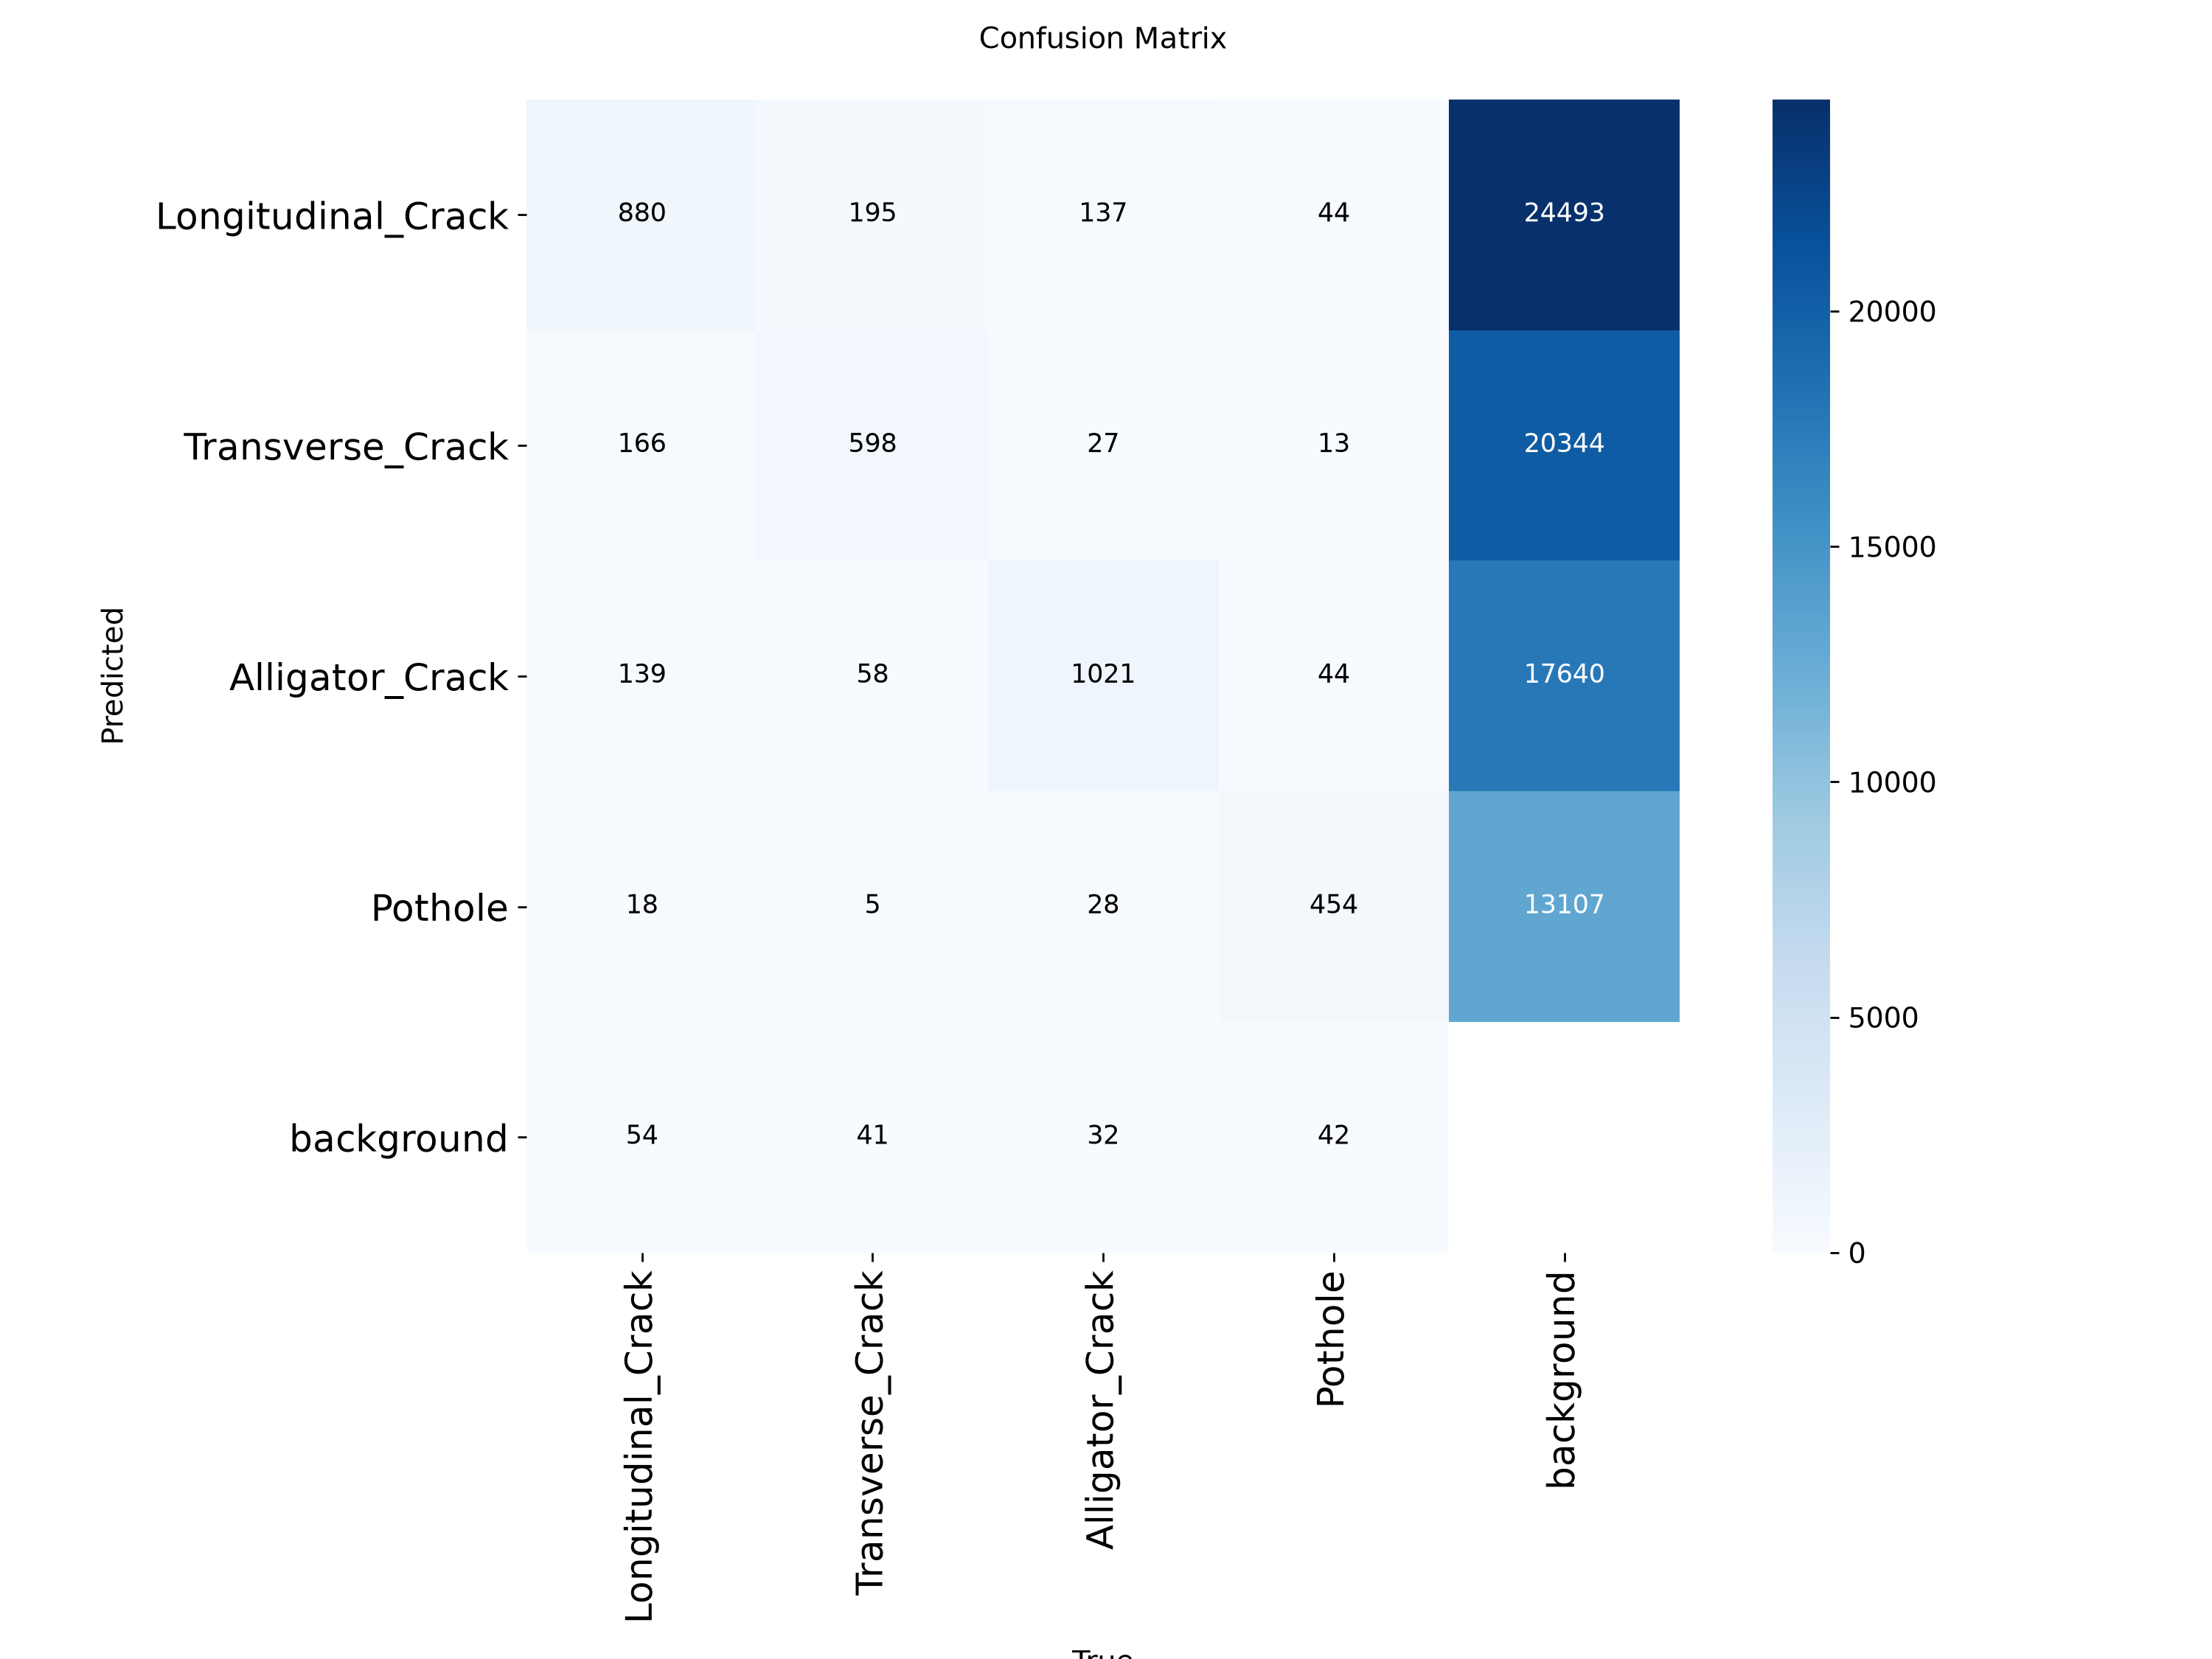

  val — confusion_matrix_normalized.png


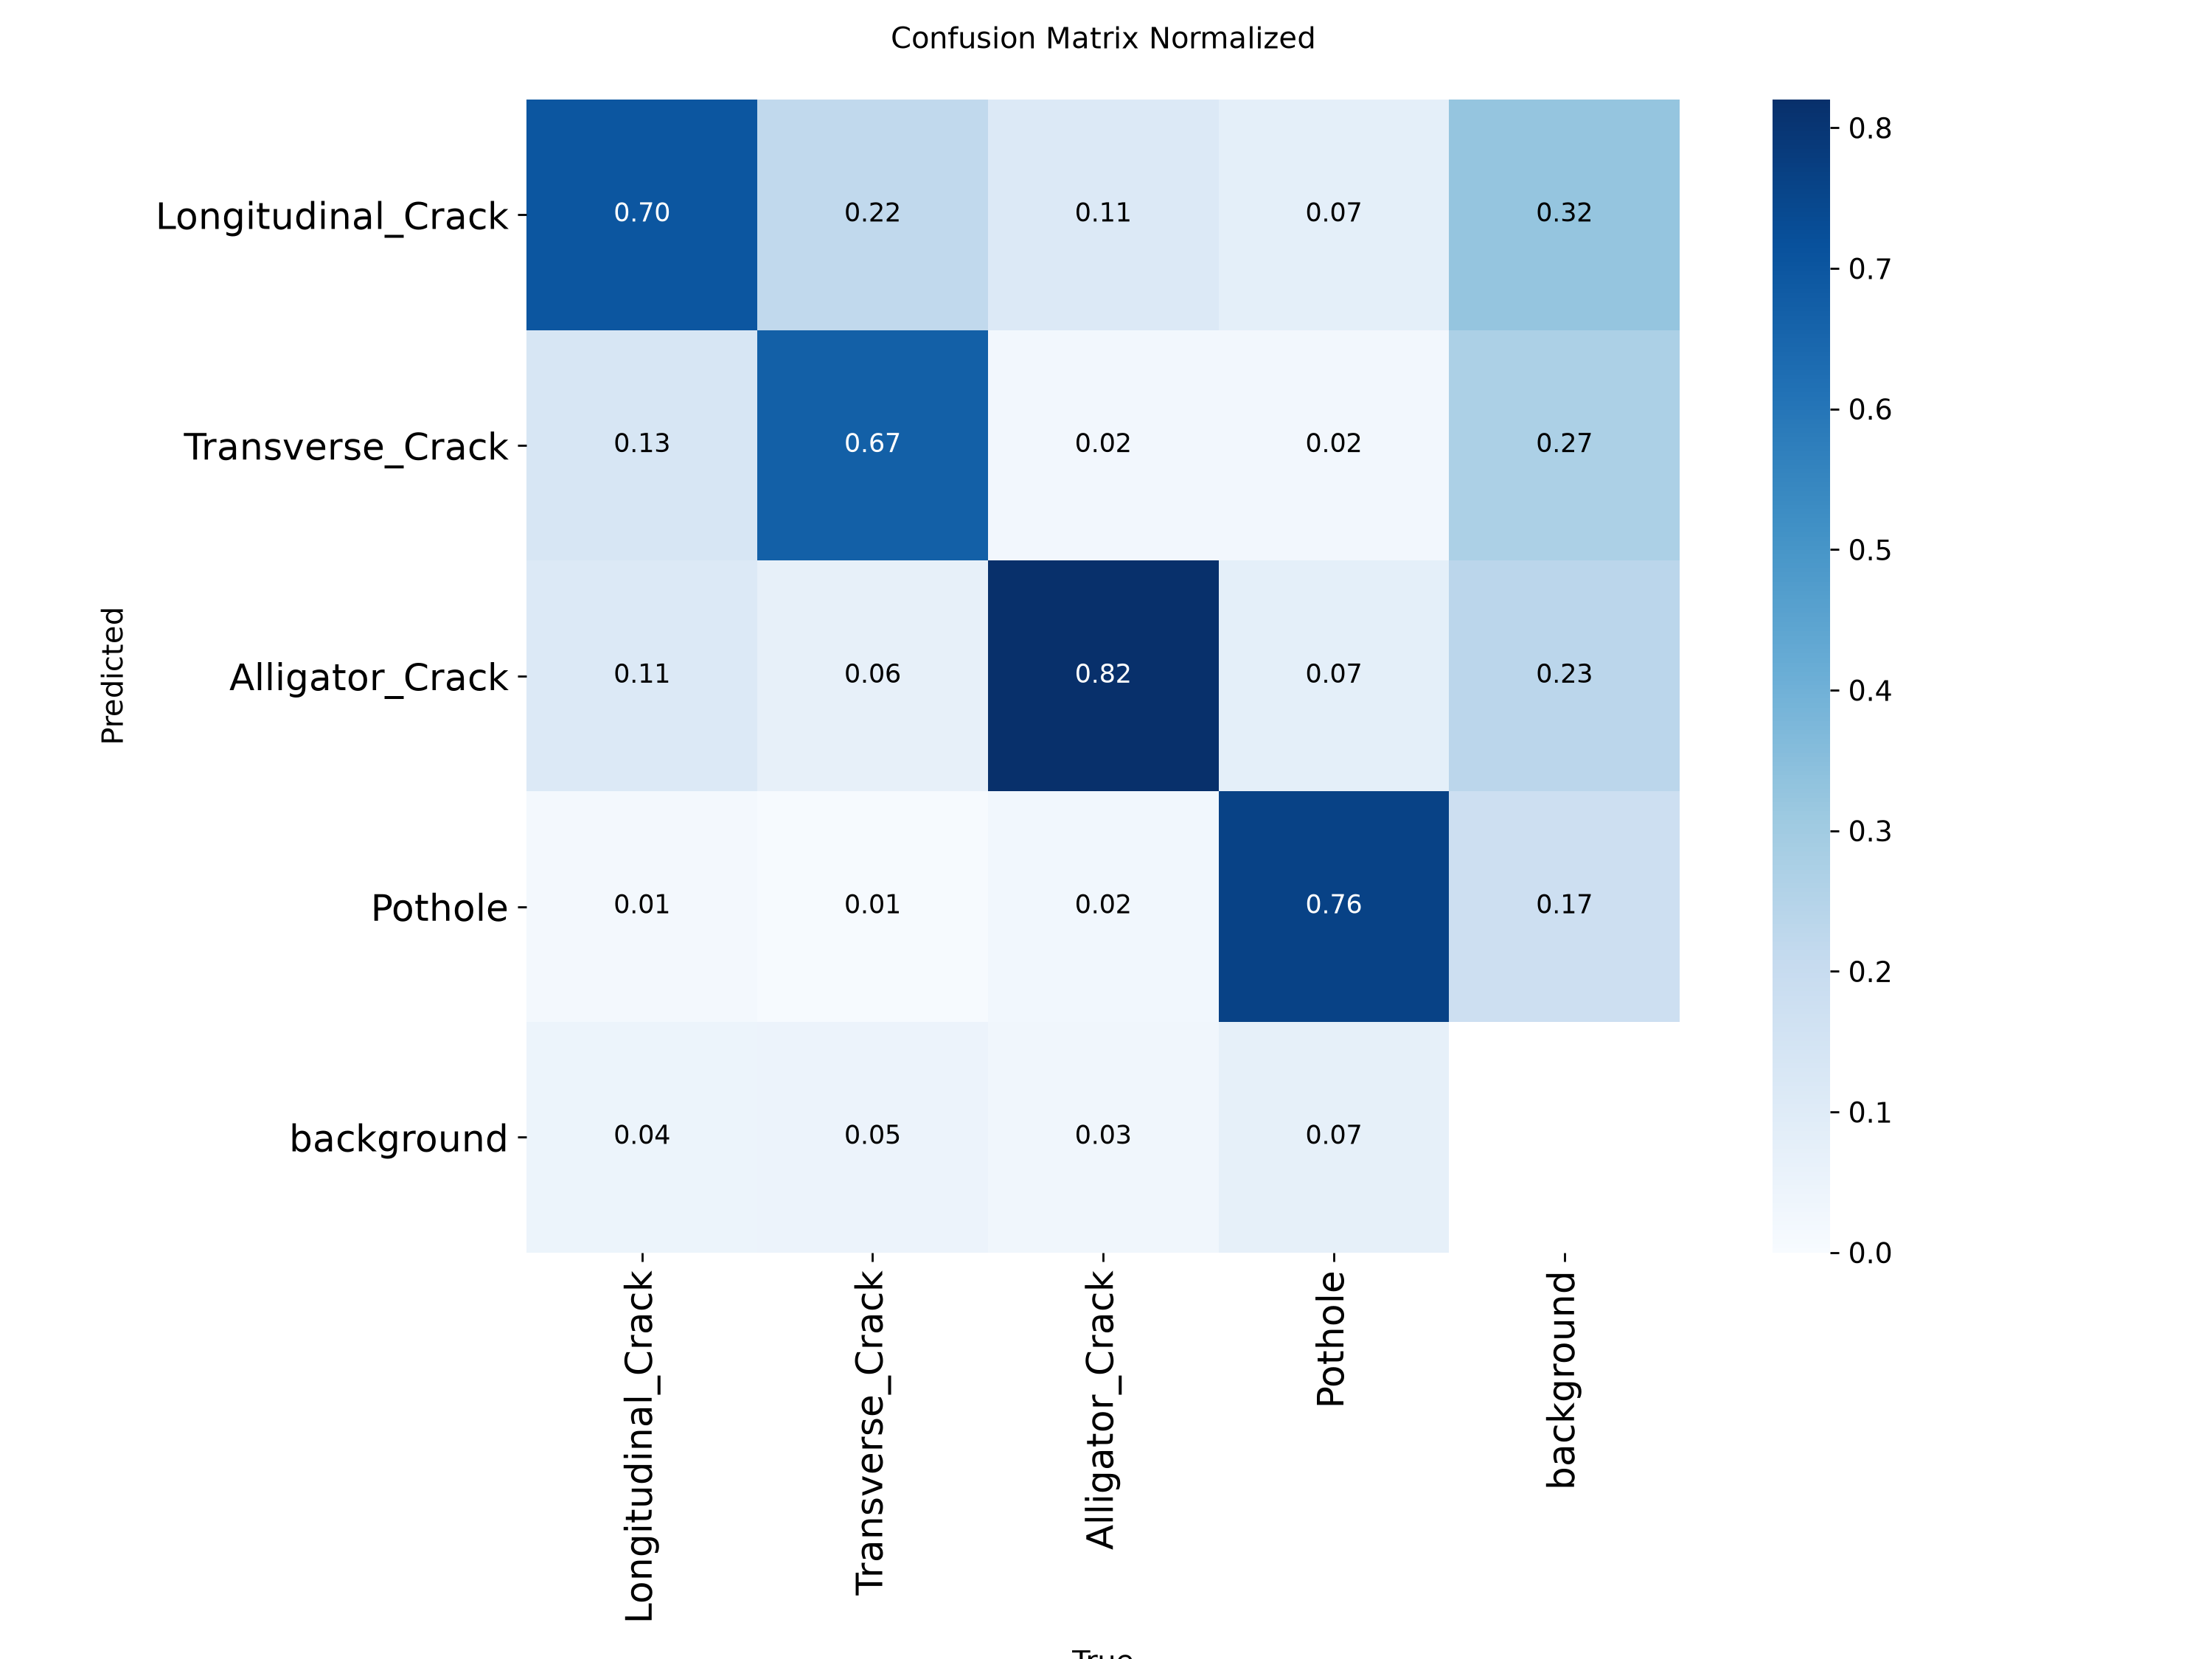

  test — confusion_matrix.png


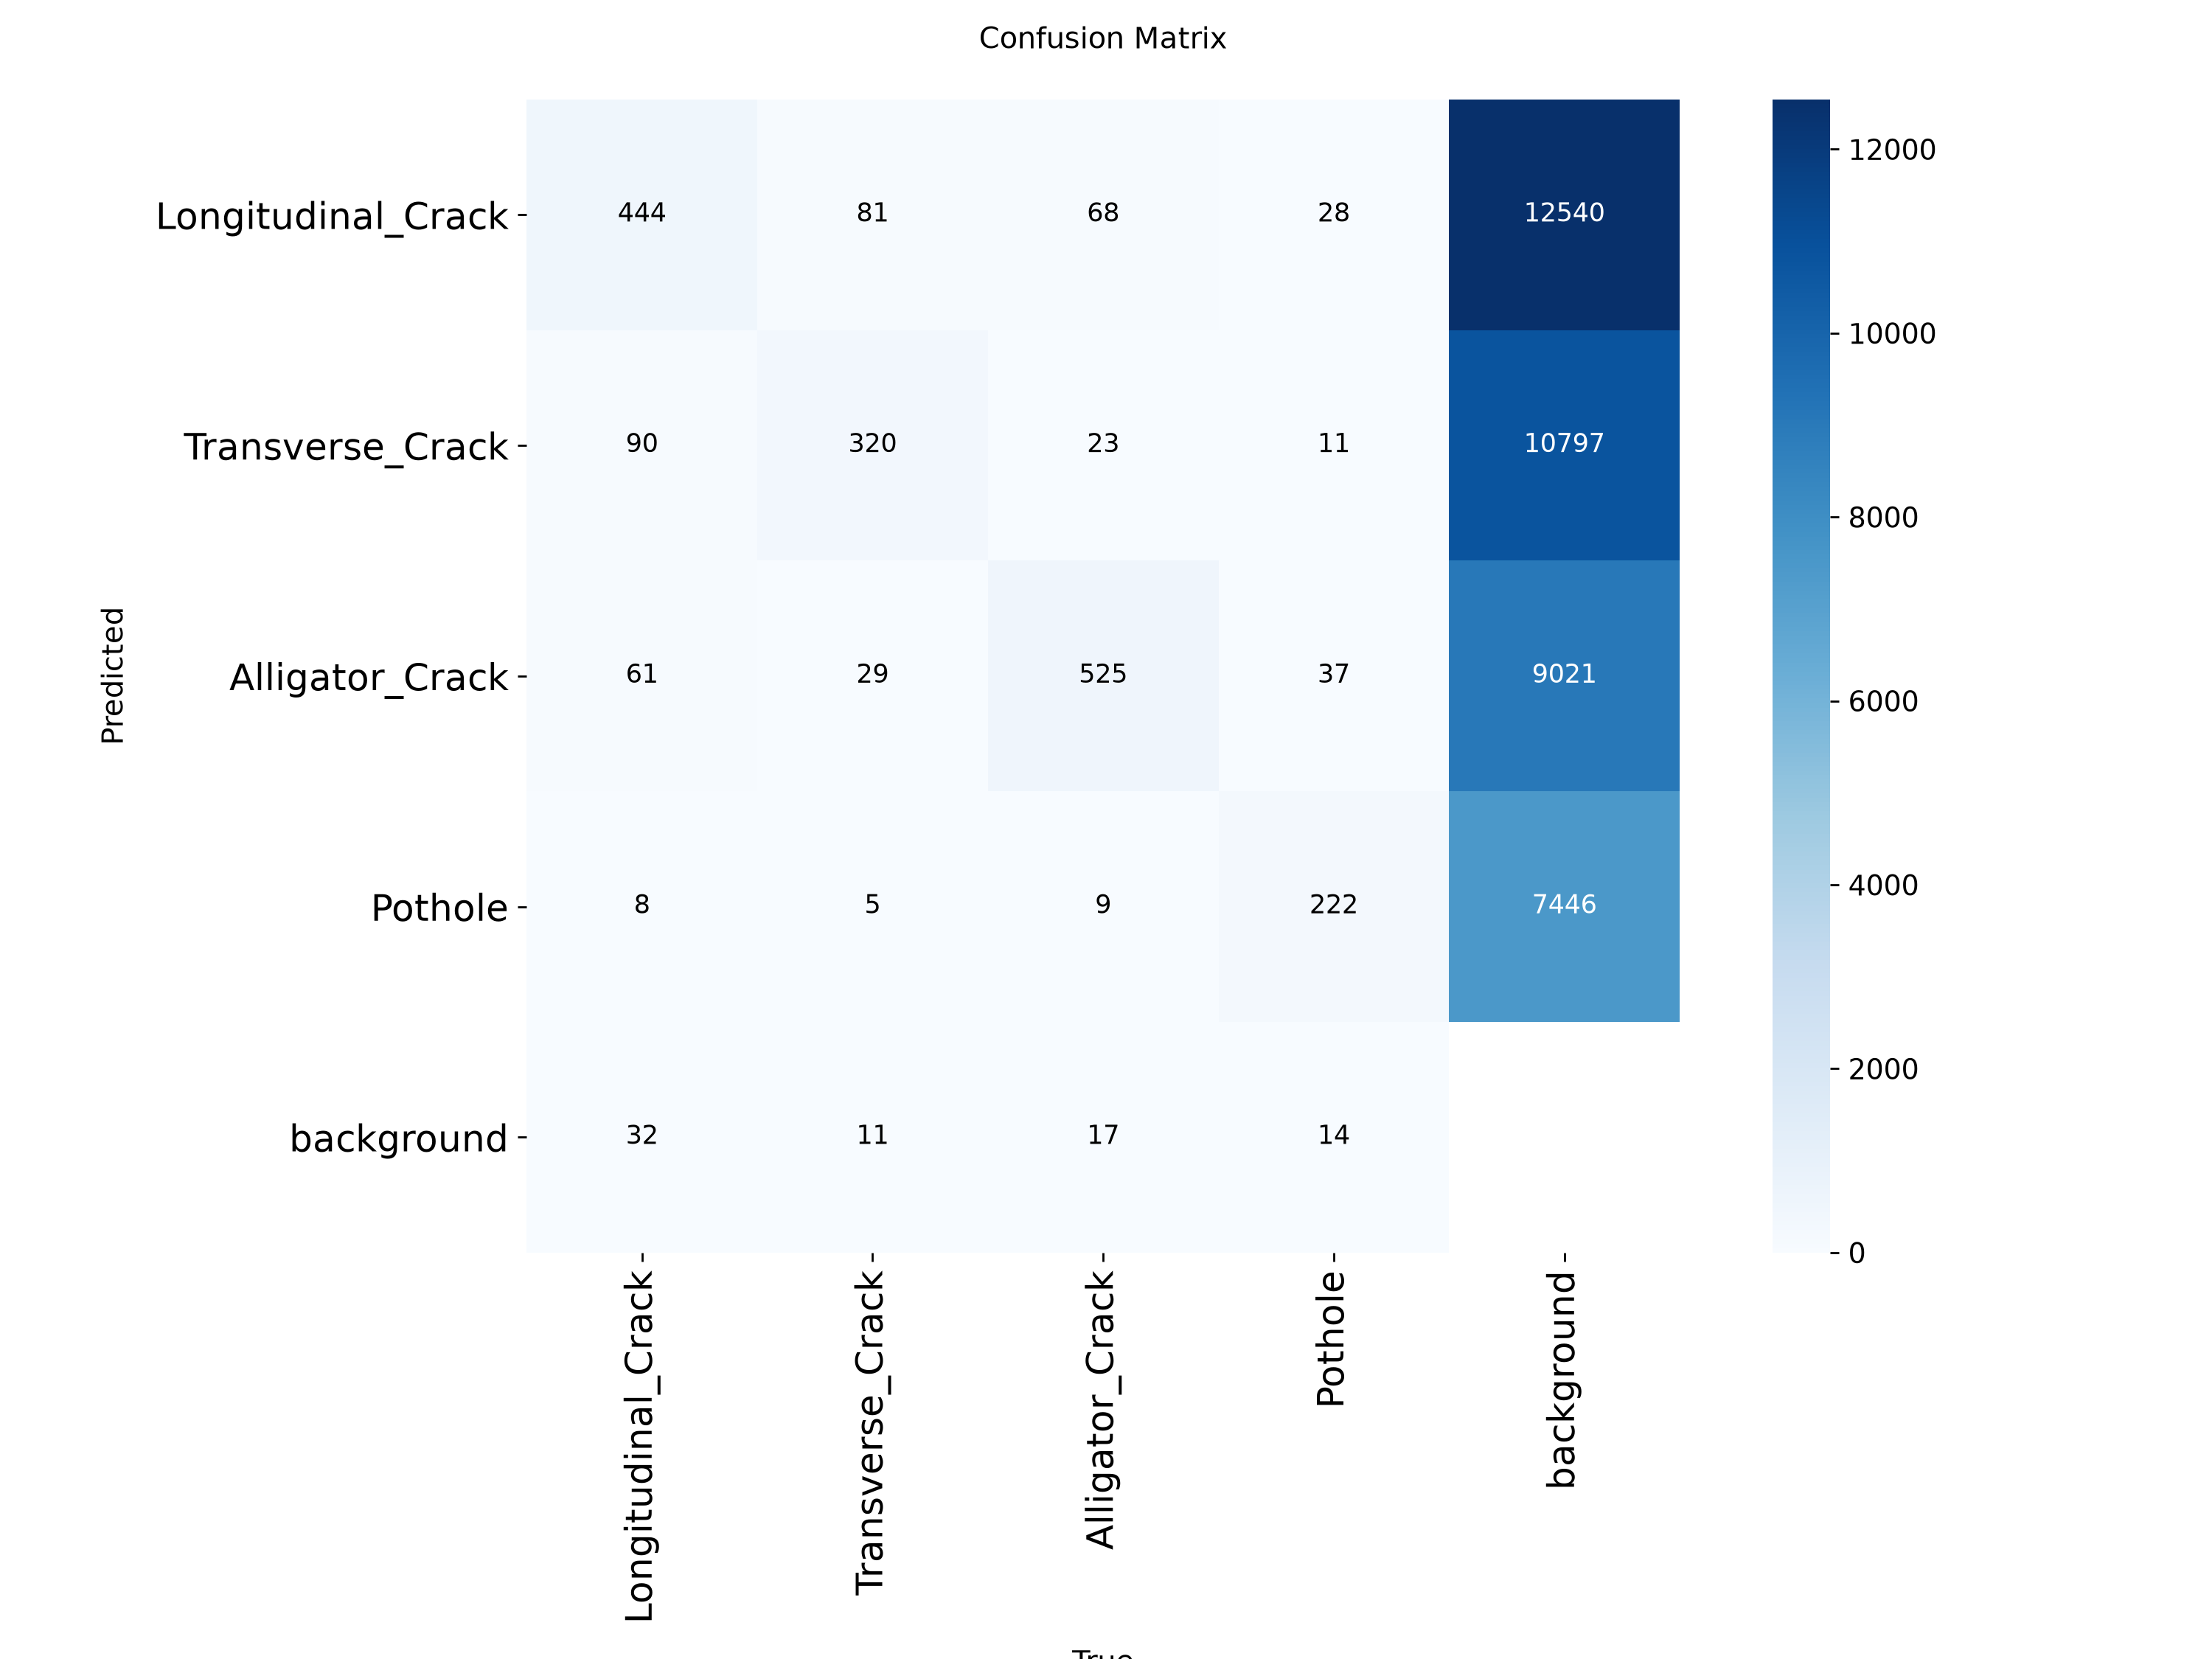

  test — confusion_matrix_normalized.png


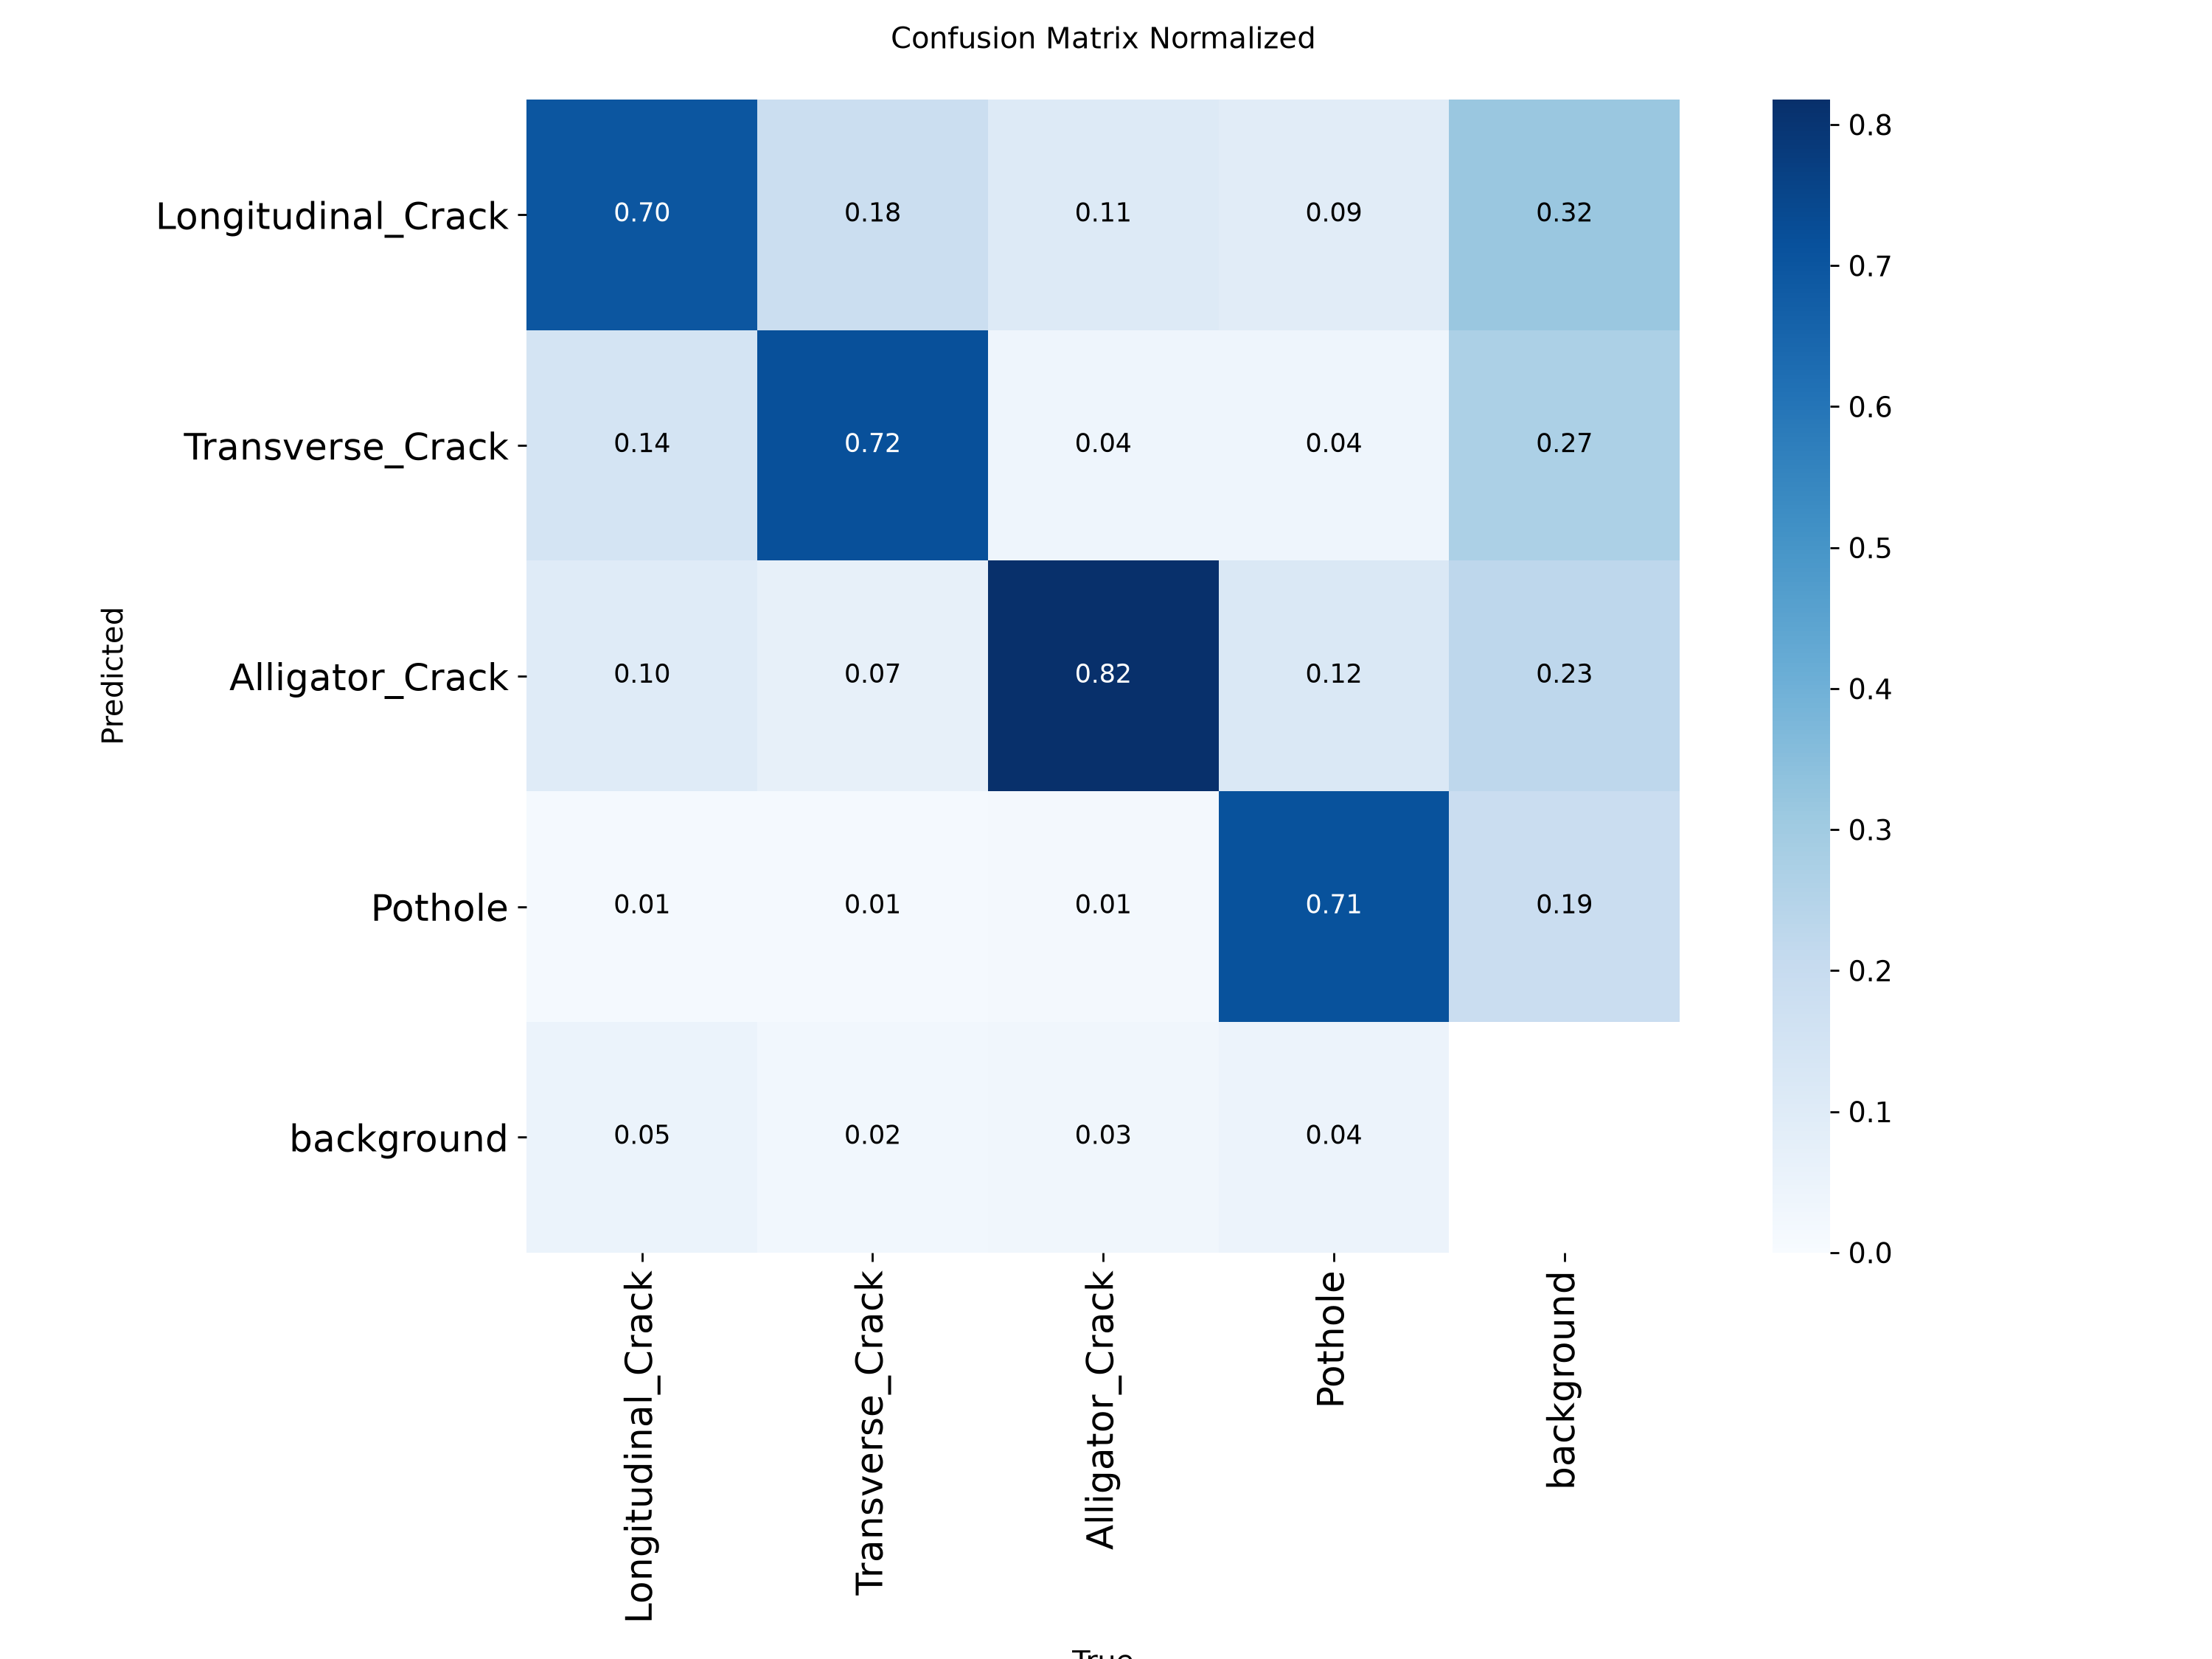


──────────────────────────────────────────────────
Model: yolov12n_4cls_class_weights
  val — confusion_matrix.png


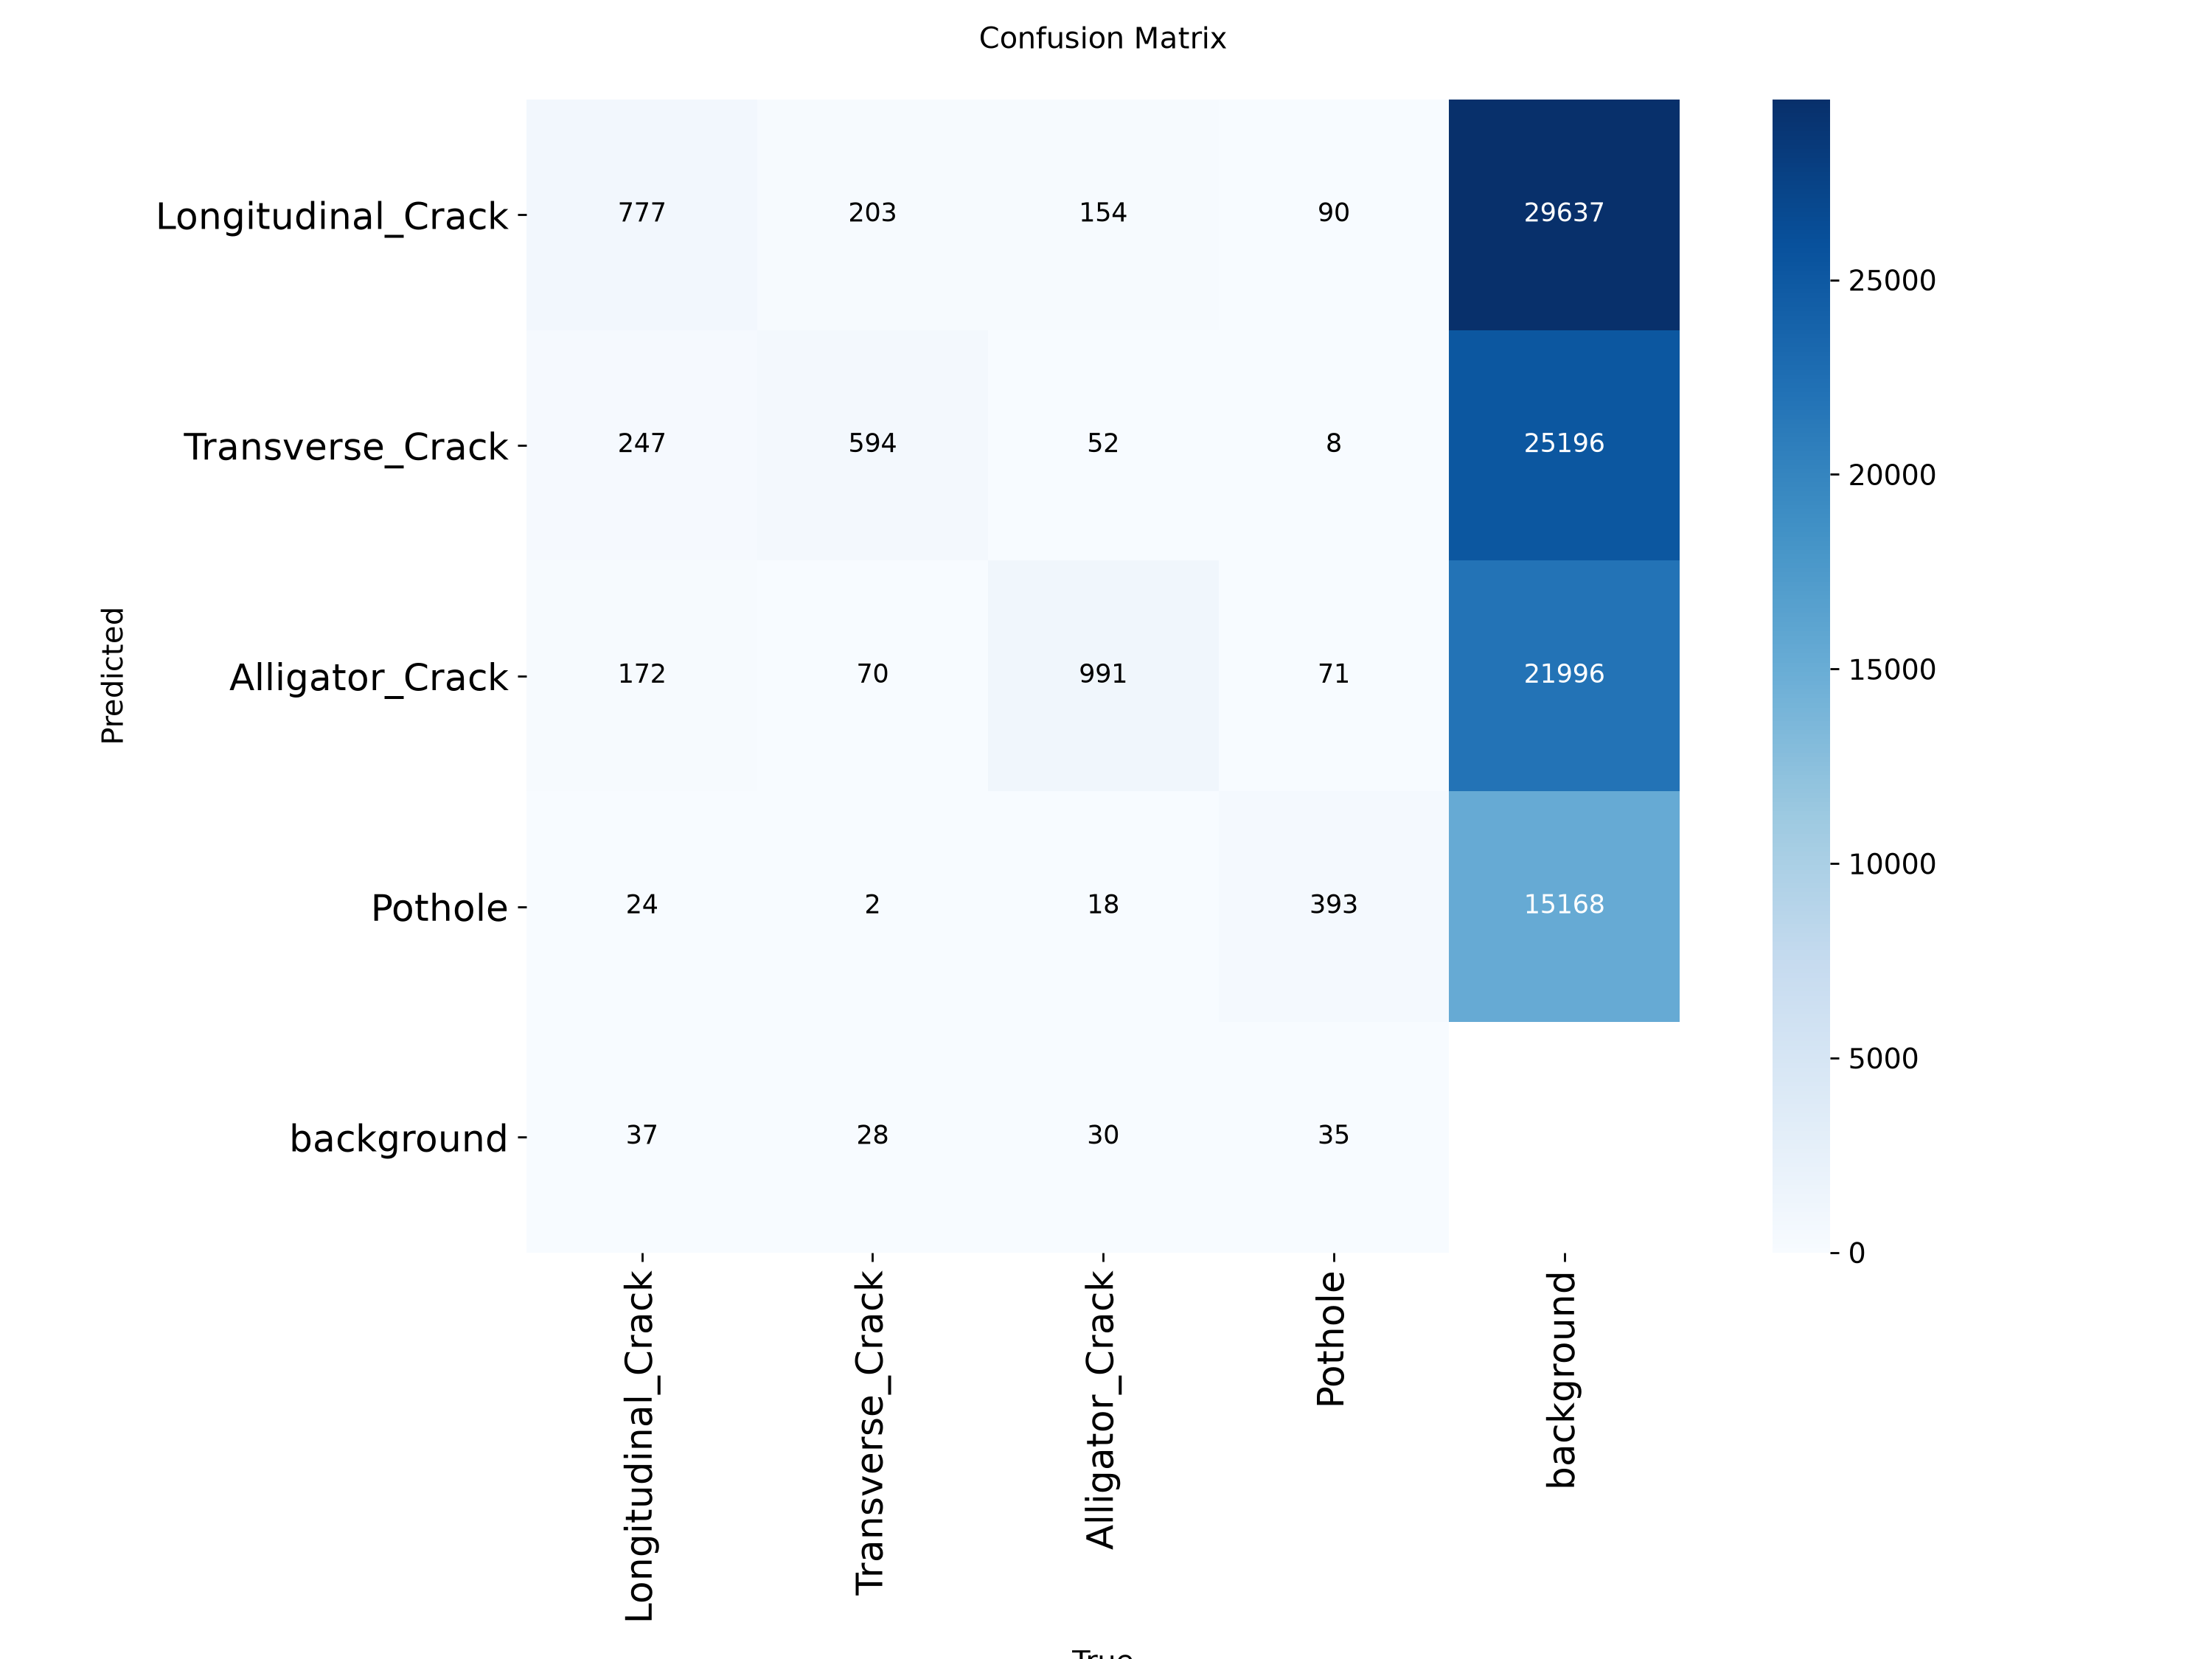

  val — confusion_matrix_normalized.png


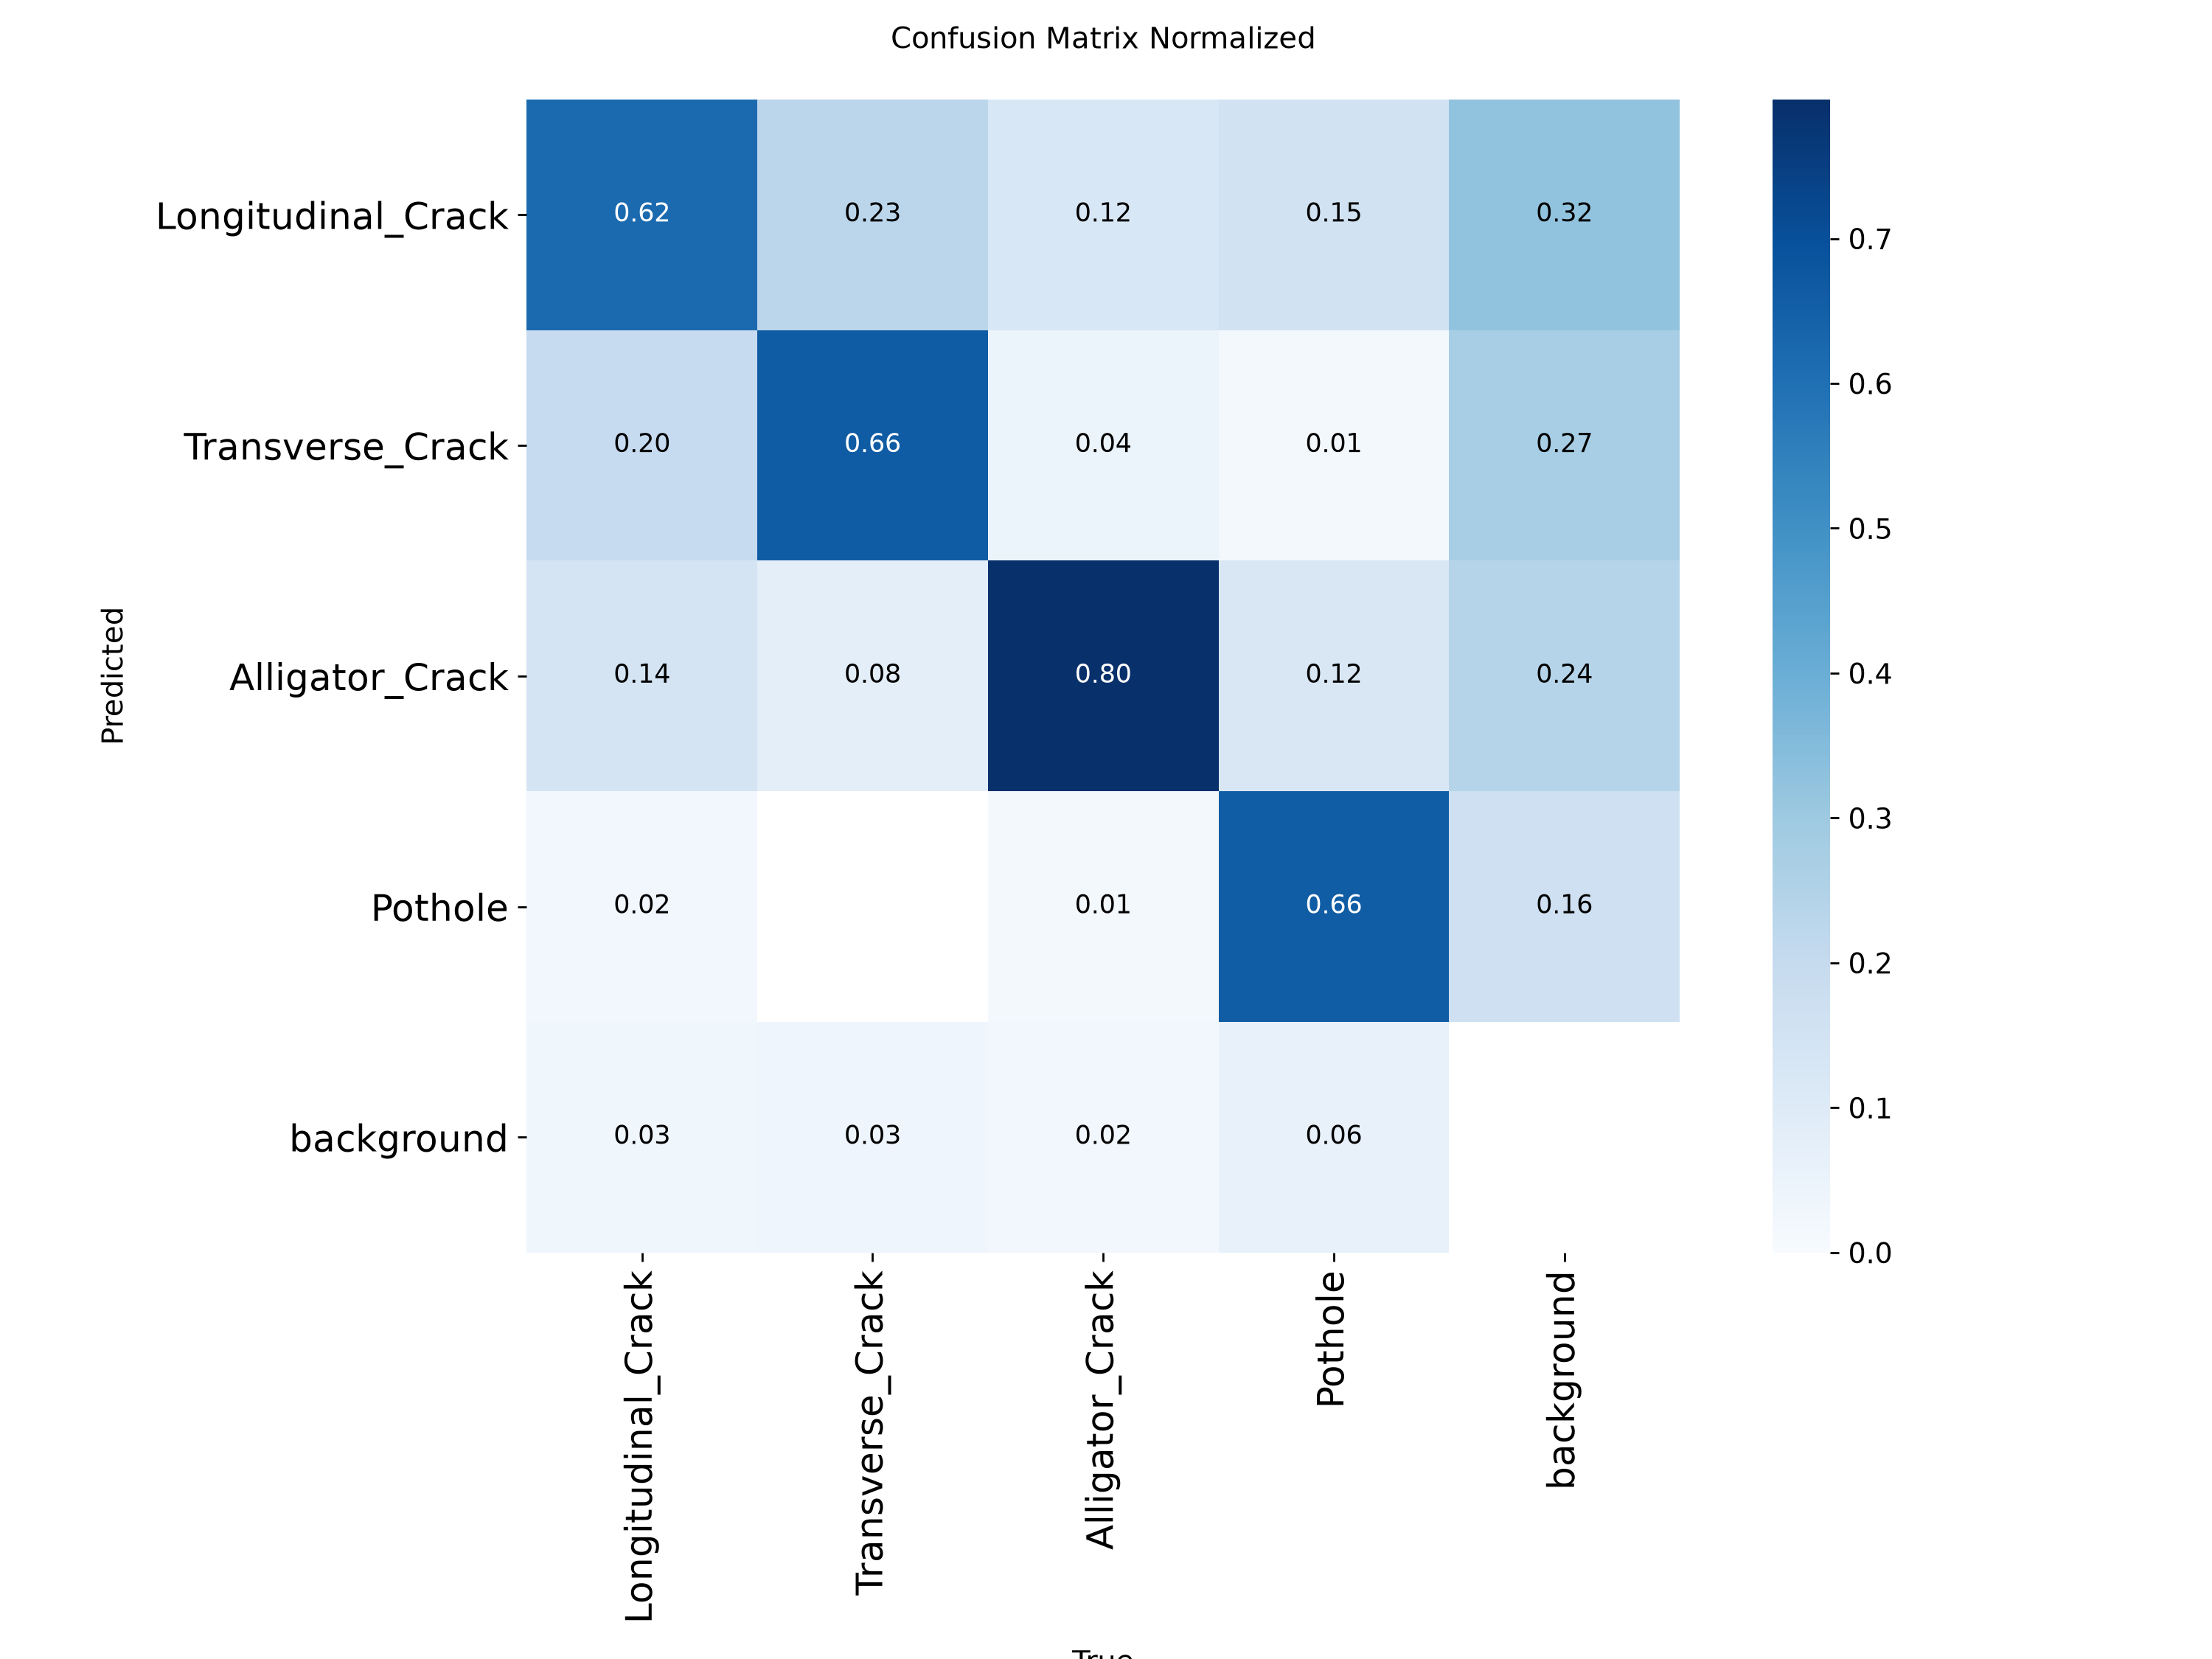

  test — confusion_matrix.png


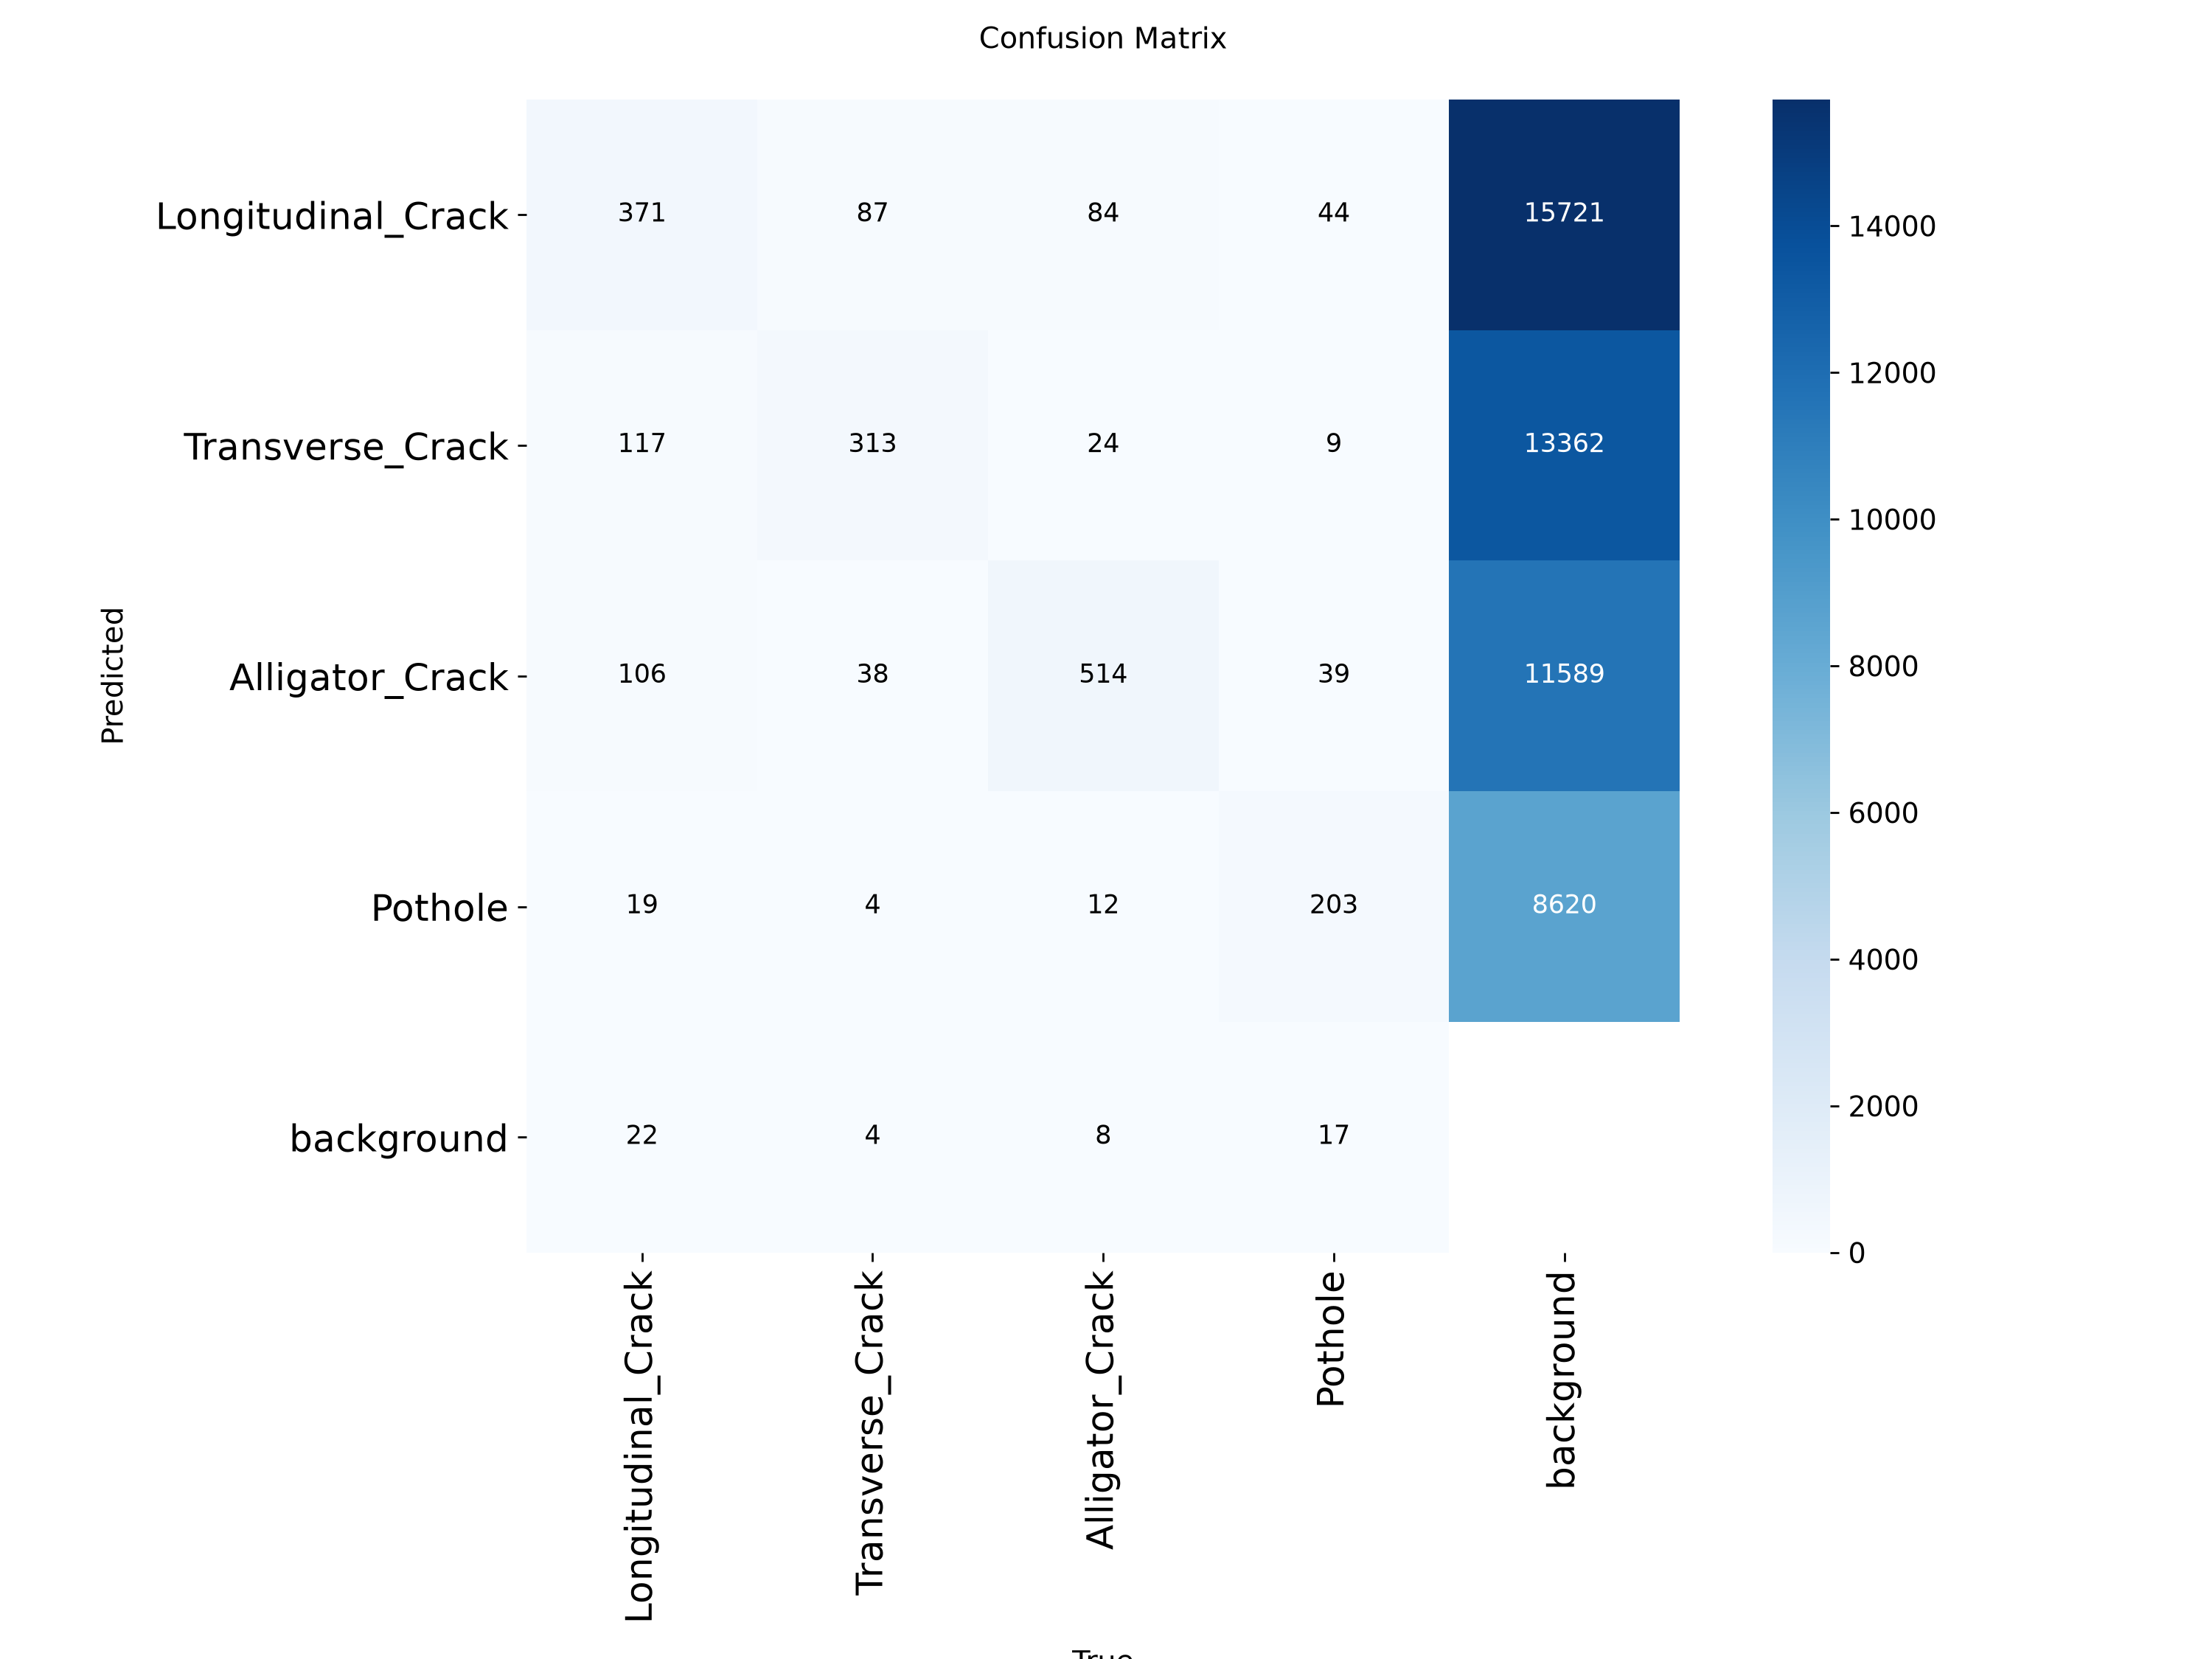

  test — confusion_matrix_normalized.png


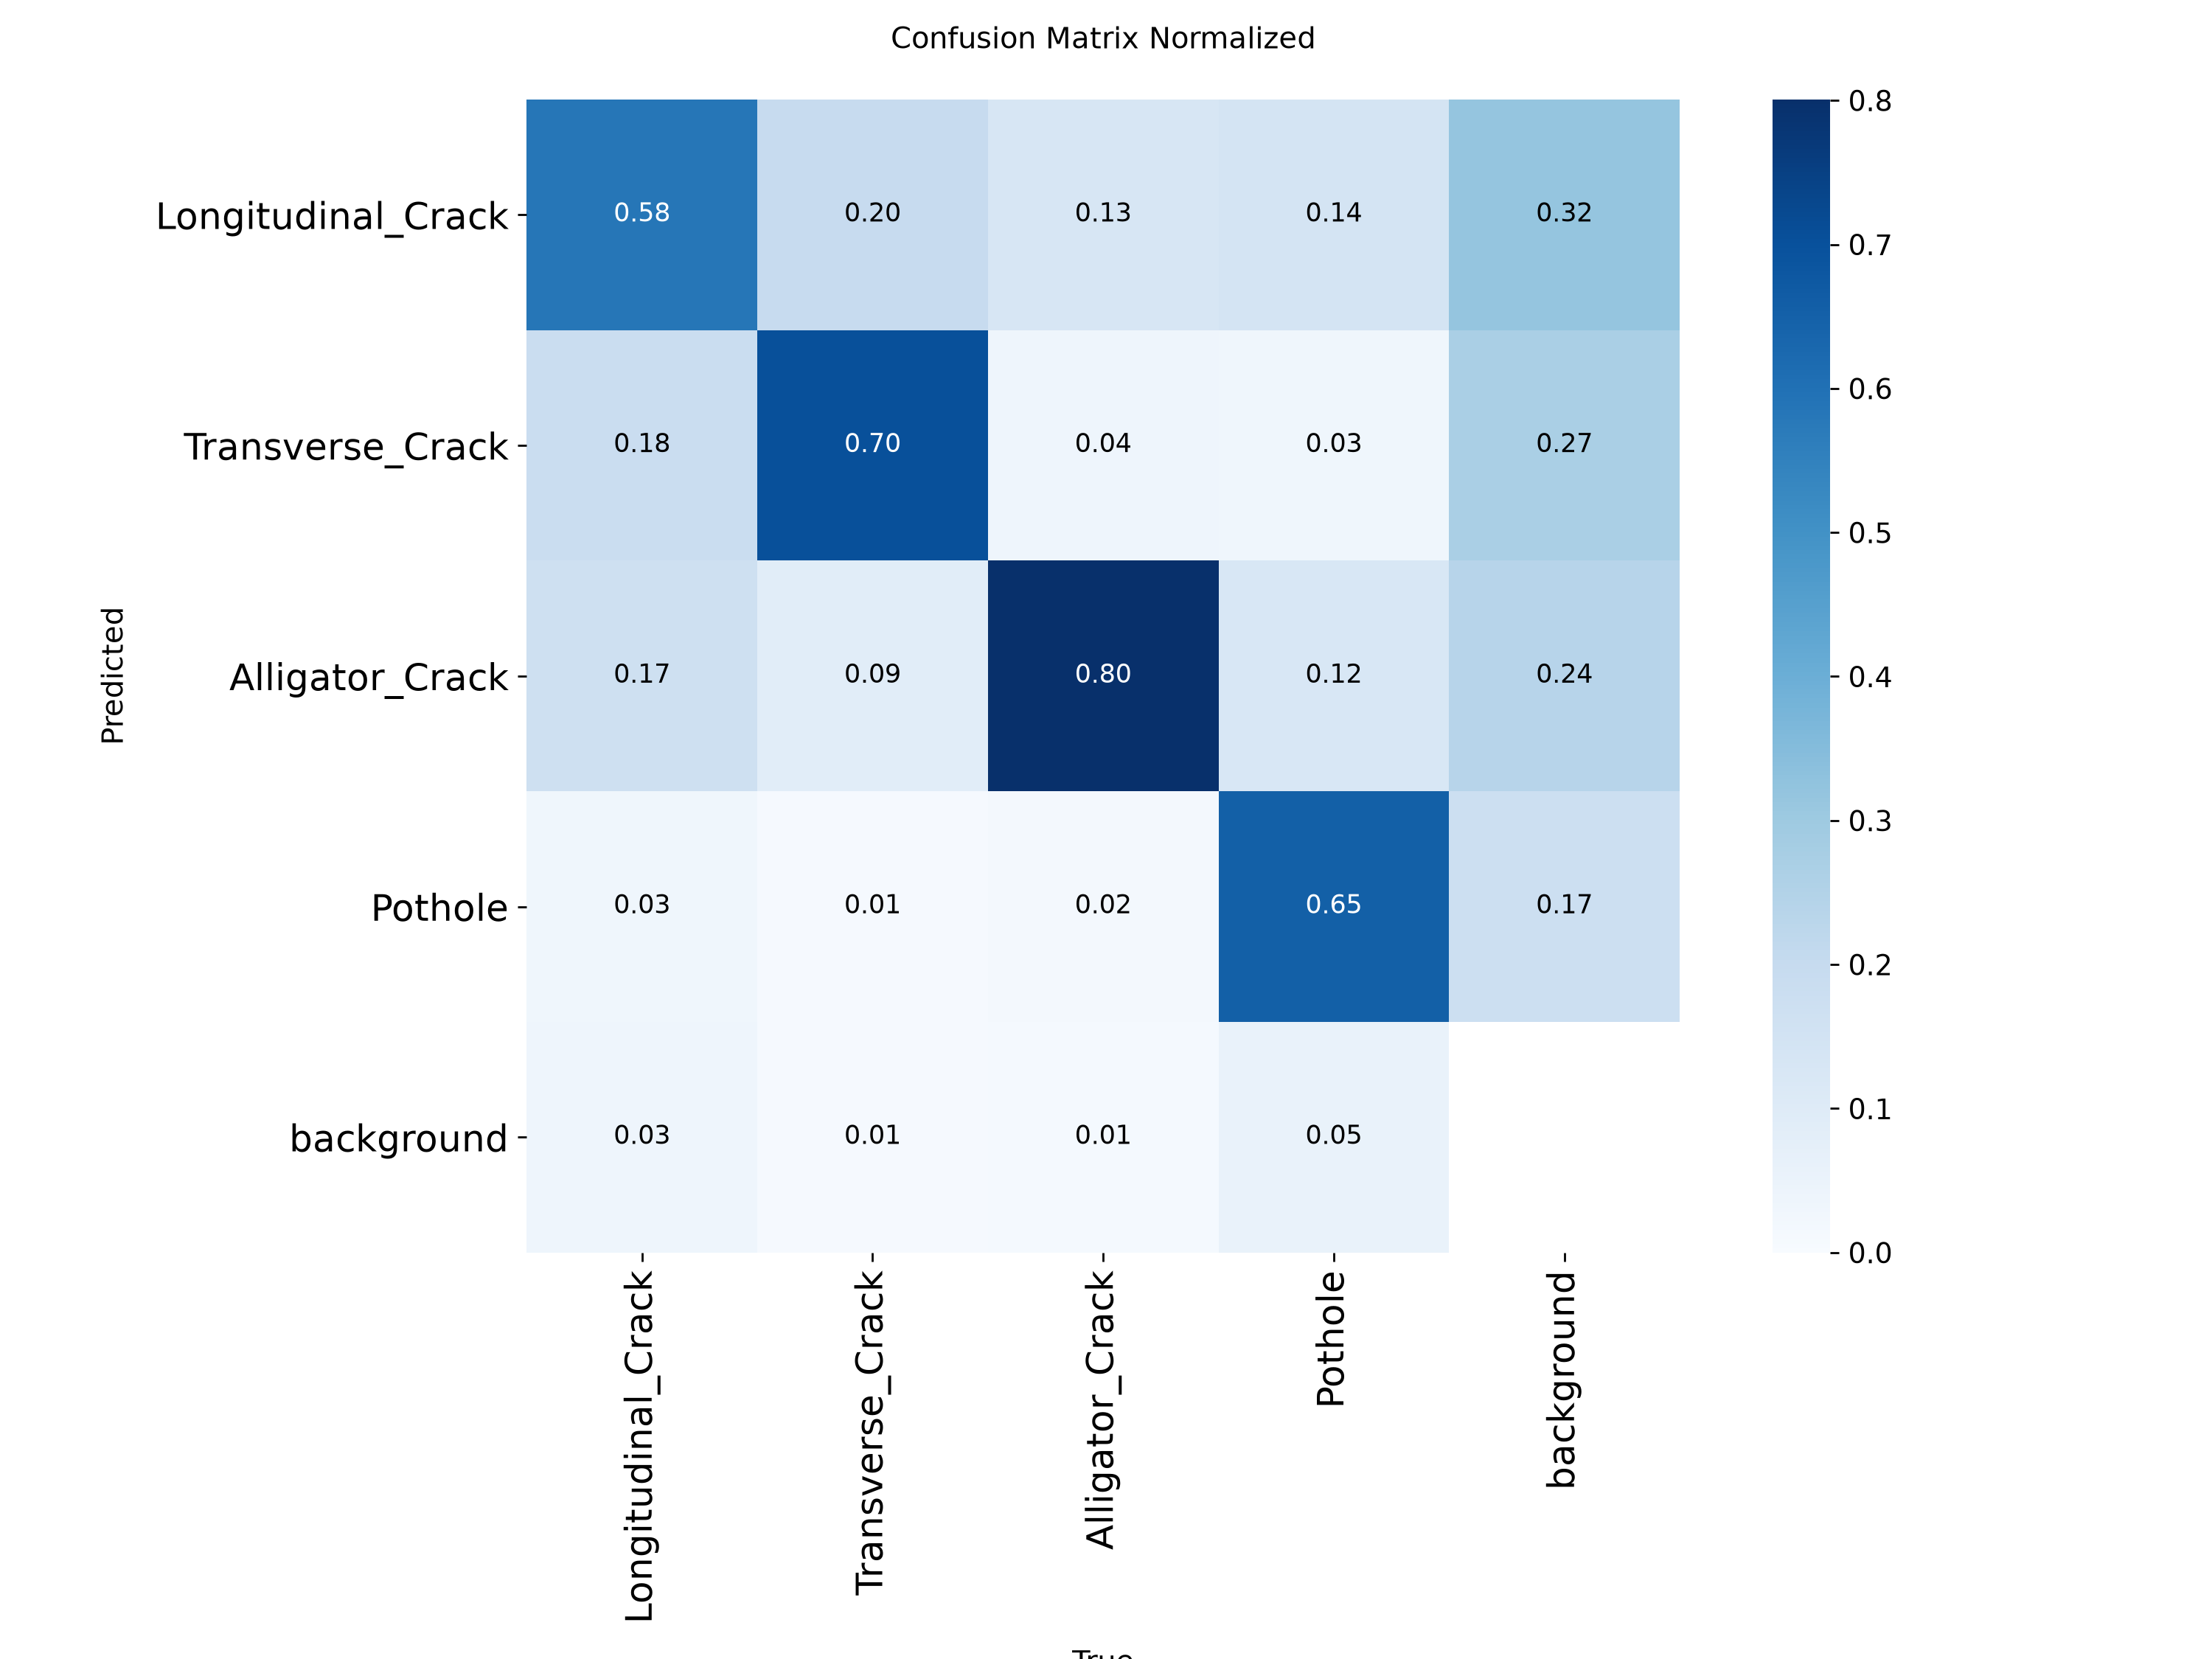

In [12]:
for model_name, run_name in trained_runs:
    print(f"\n{'─'*50}")
    print(f"Model: {model_name}")
    for split in ["val", "test"]:
        eval_subdir = EVAL_DIR / f"{model_name}_{split}"
        for plot_file in [
            "confusion_matrix.png",
            "confusion_matrix_normalized.png",
            "PR_curve.png",
            "F1_curve.png",
        ]:
            plot_path = eval_subdir / plot_file
            if plot_path.exists():
                print(f"  {split} — {plot_file}")
                display(Image(str(plot_path)))

In [21]:
# ── Kumpulkan gambar test per kelas pengecoh ──────────────────────────────────
# Scan dari dataset ASLI (6-kelas) karena DATASET_DIR (4-kelas) labelnya sudah difilter.
CONFUSION_CLASSES = {
    4: "manhole",
    5: "patchy_road",
}
POTHOLE_ID = 3         # ID Pothole di model 4-class

src_test_label_dir = SRC_DATASET_DIR / "test" / "labels"
dst_test_img_dir   = DATASET_DIR     / "test" / "images"   # hardlink ke gambar asli

confusion_images_by_class = {cid: [] for cid in CONFUSION_CLASSES}
n_gt_by_class            = {cid: 0 for cid in CONFUSION_CLASSES}
confusion_images         = []

for lp in sorted(src_test_label_dir.glob("*.txt")):
    if lp.name.lower() == "classes.txt":
        continue
    lines = lp.read_text(encoding="utf-8", errors="ignore").splitlines()
    classes_in_img = {
        int(parts[0])
        for parts in (ln.strip().split() for ln in lines if ln.strip())
        if parts and int(parts[0]) in CONFUSION_CLASSES
    }
    if not classes_in_img:
        continue
    img_path = None
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        cand = dst_test_img_dir / (lp.stem + ext)
        if cand.exists():
            img_path = cand
            break
    if img_path is None:
        continue
    for cid in classes_in_img:
        confusion_images_by_class[cid].append(img_path)
    confusion_images.append(img_path)

confusion_images = list(dict.fromkeys(confusion_images))
for cid in CONFUSION_CLASSES:
    confusion_images_by_class[cid] = list(dict.fromkeys(confusion_images_by_class[cid]))

# ── Hitung GT object per kelas pengecoh (dari label asli 6-kelas) ──
for cid, img_list in confusion_images_by_class.items():
    for img_path in img_list:
        src_lp = src_test_label_dir / (img_path.stem + ".txt")
        if not src_lp.exists():
            continue
        for line in src_lp.read_text(encoding="utf-8", errors="ignore").splitlines():
            parts = line.strip().split()
            if parts and int(parts[0]) == cid:
                n_gt_by_class[cid] += 1

for cid, name in CONFUSION_CLASSES.items():
    print(f"Gambar dengan GT {name:<12s}: {len(confusion_images_by_class[cid])}  |  GT objek: {n_gt_by_class[cid]}")
print(f"Gambar gabungan (union)  : {len(confusion_images)}  |  GT objek: {sum(n_gt_by_class.values())}")

# ── Predict dan hitung FP Pothole per model per kelas ──
PREDICT_CONF_DIR = OUTPUT_DIR / "predictions_confusion_analysis"
confusion_results = {}

# Deteksi VRAM dan tentukan device aman
free_vram_gb = torch.cuda.mem_get_info()[0] / 1024**3 if torch.cuda.is_available() else 0
ANALYSIS_DEVICE = DEVICE if free_vram_gb > 2.0 else "cpu"
print(f"VRAM bebas: {free_vram_gb:.2f} GB → menggunakan device: {ANALYSIS_DEVICE} untuk analisis ini")

BATCH_SIZE_ANALYSIS = 8

for model_name, run_name in trained_runs:
    best_weights = PROJECT_DIR / run_name / "weights/best.pt"
    best_model   = YOLO(str(best_weights))

    # Proses per batch untuk menghindari OOM
    all_preds = []
    for i in range(0, len(confusion_images), BATCH_SIZE_ANALYSIS):
        batch = [str(p) for p in confusion_images[i:i + BATCH_SIZE_ANALYSIS]]
        batch_preds = best_model.predict(
            source=batch,
            imgsz=IMGSZ,
            conf=PRED_CONF,
            iou=PRED_IOU,
            device=ANALYSIS_DEVICE,
            project=str(PREDICT_CONF_DIR),
            name=f"{model_name}_confusion_analysis",
            exist_ok=True,
            save=False,
            verbose=False,
        )
        all_preds.extend(batch_preds)

    # Peta stem gambar → jumlah prediksi Pothole.
    # Catatan: r.path tidak bisa dipakai (ultralytics menamai ulang jadi image0..N),
    # jadi hasil dipasangkan ke gambar input berdasarkan urutan (zip).
    pothole_per_stem = {}
    if len(all_preds) != len(confusion_images):
        print(f"  Peringatan: hasil prediksi {len(all_preds)} != gambar input {len(confusion_images)}")
    for r, img_path in zip(all_preds, confusion_images):
        n_pothole = int((r.boxes.cls == POTHOLE_ID).sum()) if r.boxes is not None else 0
        pothole_per_stem[img_path.stem] = n_pothole

    row = {"n_confusion_images": len(confusion_images)}
    for cid, name in CONFUSION_CLASSES.items():
        n_pred = sum(pothole_per_stem[p.stem] for p in confusion_images_by_class[cid])
        n_gt   = n_gt_by_class[cid]
        row[f"n_gt_{name}"]                   = n_gt
        row[f"n_pred_pothole_on_{name}_imgs"] = n_pred
        row[f"fp_pothole_rate_{name}"]        = round(n_pred / n_gt, 4) if n_gt > 0 else float("nan")

    n_gt_total   = sum(n_gt_by_class.values())
    n_pred_total = sum(pothole_per_stem[p.stem] for p in confusion_images)
    row["n_gt_confusion_obj"]               = n_gt_total
    row["n_pred_pothole_on_confusion_imgs"] = n_pred_total
    row["fp_pothole_rate"]                  = round(n_pred_total / n_gt_total, 4) if n_gt_total > 0 else float("nan")

    confusion_results[model_name] = row

    print(f"{'-'*50}")
    print(f"Model: {model_name}")
    for cid, name in CONFUSION_CLASSES.items():
        n_pred = row[f"n_pred_pothole_on_{name}_imgs"]
        n_gt   = row[f"n_gt_{name}"]
        rate   = row[f"fp_pothole_rate_{name}"]
        print(f"  {name:<12s}: Pothole FP={n_pred}, GT={n_gt}, rate={rate}")
    print(f"  Gabungan    : Pothole FP={n_pred_total}, GT={n_gt_total}, rate={row['fp_pothole_rate']}")

    del best_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

confusion_df = pd.DataFrame.from_dict(confusion_results, orient="index").reset_index()
confusion_df = confusion_df.rename(columns={"index": "model"})
display(confusion_df)
confusion_df.to_csv(OUTPUT_DIR / "confusion_pothole_analysis.csv", index=False)
print("Disimpan ke confusion_pothole_analysis.csv")

Gambar dengan GT manhole     : 234  |  GT objek: 321
Gambar dengan GT patchy_road : 52  |  GT objek: 69
Gambar gabungan (union)  : 272  |  GT objek: 390
VRAM bebas: 10.33 GB → menggunakan device: 0 untuk analisis ini
--------------------------------------------------
Model: yolov26n_4cls_class_weights
  manhole     : Pothole FP=51, GT=321, rate=0.1589
  patchy_road : Pothole FP=13, GT=69, rate=0.1884
  Gabungan    : Pothole FP=58, GT=390, rate=0.1487


,model,n_confusion_images,n_gt_manhole,n_pred_pothole_on_manhole_imgs,fp_pothole_rate_manhole,n_gt_patchy_road,n_pred_pothole_on_patchy_road_imgs,fp_pothole_rate_patchy_road,n_gt_confusion_obj,n_pred_pothole_on_confusion_imgs,fp_pothole_rate
0,yolov26n_4cls_class_weights,272,321,51,0.1589,69,13,0.1884,390,58,0.1487


Disimpan ke confusion_pothole_analysis.csv


In [ ]:
# # ── Kumpulkan gambar test yang GT-nya ada manhole (ID 4) atau patchy_road (ID 5) ──
# # Scan dari dataset ASLI (6-kelas) karena DATASET_DIR (4-kelas) labelnya sudah difilter.
# CONFUSION_IDS   = {4, 5}   # ID kelas pengecoh di dataset original (6-kelas)
# POTHOLE_ID      = 3         # ID Pothole di model 4-class

# src_test_label_dir = SRC_DATASET_DIR / "test" / "labels"
# dst_test_img_dir   = DATASET_DIR     / "test" / "images"   # hardlink ke gambar asli

# confusion_images = []

# for lp in sorted(src_test_label_dir.glob("*.txt")):
#     if lp.name.lower() == "classes.txt":
#         continue
#     lines = lp.read_text(encoding="utf-8", errors="ignore").splitlines()
#     has_confusion = any(
#         parts and int(parts[0]) in CONFUSION_IDS
#         for parts in (ln.strip().split() for ln in lines if ln.strip())
#     )
#     if has_confusion:
#         for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
#             img_path = dst_test_img_dir / (lp.stem + ext)
#             if img_path.exists():
#                 confusion_images.append(img_path)
#                 break

# confusion_images = list(dict.fromkeys(confusion_images))  # deduplicate
# print(f"Gambar test yang memuat manhole/patchy_road: {len(confusion_images)}")

# # ── Hitung GT object manhole/patchy total (dari label asli 6-kelas) ──
# n_gt_confusion = 0
# for img_path in confusion_images:
#     src_lp = src_test_label_dir / (img_path.stem + ".txt")
#     if src_lp.exists():
#         for line in src_lp.read_text(encoding="utf-8", errors="ignore").splitlines():
#             parts = line.strip().split()
#             if parts and int(parts[0]) in CONFUSION_IDS:
#                 n_gt_confusion += 1

# print(f"Total GT object manhole/patchy_road pada gambar tersebut: {n_gt_confusion}")

# # ── Predict dan hitung FP Pothole per model ──
# PREDICT_CONF_DIR = OUTPUT_DIR / "predictions_confusion_analysis"
# confusion_results = {}

# for model_name, run_name in trained_runs:
#     best_weights = PROJECT_DIR / run_name / "weights/best.pt"
#     best_model   = YOLO(str(best_weights))

#     preds = best_model.predict(
#         source=[str(p) for p in confusion_images],
#         imgsz=IMGSZ,
#         conf=PRED_CONF,
#         iou=PRED_IOU,
#         device=DEVICE,
#         project=str(PREDICT_CONF_DIR),
#         name=f"{model_name}_confusion_analysis",
#         exist_ok=True,
#         save=False,
#         verbose=False,
#     )

#     n_pred_pothole = sum(
#         int((r.boxes.cls == POTHOLE_ID).sum()) for r in preds if r.boxes is not None
#     )
#     fp_rate = n_pred_pothole / n_gt_confusion if n_gt_confusion > 0 else float("nan")

#     confusion_results[model_name] = {
#         "n_confusion_images":               len(confusion_images),
#         "n_gt_confusion_obj":               n_gt_confusion,
#         "n_pred_pothole_on_confusion_imgs": n_pred_pothole,
#         "fp_pothole_rate":                  round(fp_rate, 4),
#     }
#     print(f"\n{'─'*50}")
#     print(f"Model: {model_name}")
#     print(f"  Prediksi Pothole pada gambar manhole/patchy : {n_pred_pothole}")
#     print(f"  Total GT manhole/patchy                     : {n_gt_confusion}")
#     print(f"  FP Pothole rate                             : {fp_rate:.4f}")

#     del best_model
#     gc.collect()
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

# confusion_df = pd.DataFrame.from_dict(confusion_results, orient="index").reset_index()
# confusion_df.columns = ["model", "n_confusion_images", "n_gt_confusion_obj",
#                          "n_pred_pothole_on_confusion_imgs", "fp_pothole_rate"]
# display(confusion_df)
# confusion_df.to_csv(OUTPUT_DIR / "confusion_pothole_analysis.csv", index=False)
# print("\nDisimpan ke confusion_pothole_analysis.csv")


### ***Prediksi Sampel Test per Model***


0: 640x640 2 Longitudinal_Cracks, 1 Transverse_Crack, 1 Alligator_Crack, 32.7ms
1: 640x640 2 Transverse_Cracks, 32.7ms
2: 640x640 2 Transverse_Cracks, 1 Alligator_Crack, 32.7ms
3: 640x640 1 Transverse_Crack, 32.7ms
4: 640x640 1 Alligator_Crack, 32.7ms
5: 640x640 2 Alligator_Cracks, 32.7ms
Speed: 2.7ms preprocess, 32.7ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\Faaris\Project-TA\road-damage-detection-ta\runs\rdd_4class_local\predictions\yolov26n_4cls_class_weights_test_samples
6 labels saved to D:\Faaris\Project-TA\road-damage-detection-ta\runs\rdd_4class_local\predictions\yolov26n_4cls_class_weights_test_samples\labels

──────────────────────────────────────────────────
Model: yolov26n_4cls_class_weights — prediksi sampel test (PRED_CONF=0.25, PRED_IOU=0.6)


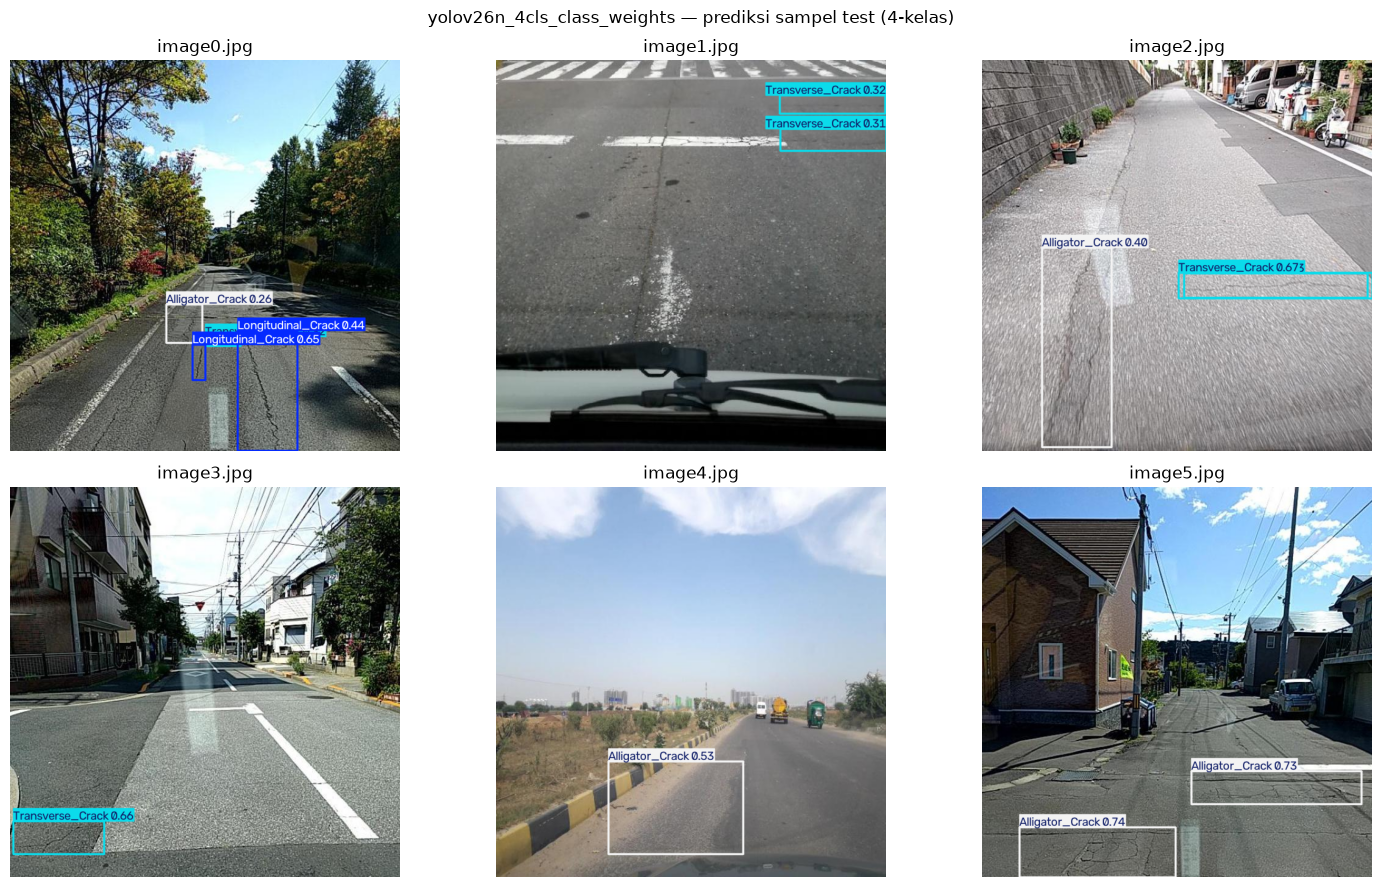

In [22]:
PREDICT_DIR   = OUTPUT_DIR / "predictions"
N_PRED_IMAGES = 6
test_images   = list_images("test")
sample_test   = random.sample(test_images, k=min(N_PRED_IMAGES, len(test_images)))

for model_name, run_name in trained_runs:
    best_weights = PROJECT_DIR / run_name / "weights/best.pt"
    best_model   = YOLO(str(best_weights))

    results = best_model.predict(
        source=[str(p) for p in sample_test],
        imgsz=IMGSZ,
        conf=PRED_CONF,
        iou=PRED_IOU,
        device=DEVICE,
        project=str(PREDICT_DIR),
        name=f"{model_name}_test_samples",
        exist_ok=True,
        save=True,
        save_txt=True,
        save_conf=True,
    )

    print(f"\n{'─'*50}")
    print(f"Model: {model_name} — prediksi sampel test ({PRED_CONF=}, {PRED_IOU=})")
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()
    for ax, r in zip(axes, results):
        ax.imshow(r.plot()[:, :, ::-1])
        ax.set_title(Path(r.path).name[:45])
        ax.axis("off")
    for ax in axes[len(results):]:
        ax.axis("off")
    plt.suptitle(f"{model_name} — prediksi sampel test (4-kelas)")
    plt.tight_layout()
    plt.show()

### ***Confidence Sweep (Opsional)***

In [23]:
RUN_CONFIDENCE_SWEEP = False
CONF_SWEEP = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

if RUN_CONFIDENCE_SWEEP:
    for model_name, run_name in trained_runs:
        best_weights = PROJECT_DIR / run_name / "weights/best.pt"
        best_model   = YOLO(str(best_weights))
        rows = []
        for conf in CONF_SWEEP:
            metrics = best_model.val(
                data=str(local_yaml),
                split="test",
                imgsz=IMGSZ,
                batch=BATCH,
                device=DEVICE,
                workers=WORKERS,
                project=str(EVAL_DIR),
                name=f"{model_name}_conf_{conf:.2f}".replace(".", "p"),
                exist_ok=True,
                plots=False,
                save_json=False,
                conf=conf,
                iou=EVAL_IOU,
                verbose=False,
            )
            rows.append({"model": model_name, "conf": conf, **{k: float(v) for k, v in metrics.results_dict.items()}})
        conf_sweep_df = pd.DataFrame(rows)
        display(conf_sweep_df)
        conf_sweep_df.to_csv(OUTPUT_DIR / f"{model_name}_confidence_sweep_test.csv", index=False)
else:
    print("Confidence sweep dilewati. Set RUN_CONFIDENCE_SWEEP=True jika ingin menjalankan.")

Confidence sweep dilewati. Set RUN_CONFIDENCE_SWEEP=True jika ingin menjalankan.


## ***Template Zero-Shot Bandung***

---

Jika data primer Bandung sudah diberi label YOLO, buat struktur berikut:

```
data/primary_bandung_yolo/
  data.yaml
  test/images/
  test/labels/
```

Lalu isi `PRIMARY_DATA_YAML`. Jika data primer belum berlabel, gunakan mode `predict` untuk inspeksi kualitatif.

In [24]:
PRIMARY_DATA_YAML  = REPO_ROOT / "data/primary_bandung_yolo/data.yaml"
PRIMARY_IMAGES_DIR = REPO_ROOT / "data/primary_bandung_yolo/images"

# Gunakan model terbaik (model pertama di trained_runs) untuk zero-shot.
# Ubah indeks jika ingin model yang berbeda.
if trained_runs:
    zs_model_name, zs_run_name = trained_runs[0]
    zs_weights = PROJECT_DIR / zs_run_name / "weights/best.pt"
    zs_model   = YOLO(str(zs_weights))

    if PRIMARY_DATA_YAML.exists():
        zero_shot_metrics = zs_model.val(
            data=str(PRIMARY_DATA_YAML),
            split="test",
            imgsz=IMGSZ,
            batch=BATCH,
            device=DEVICE,
            workers=WORKERS,
            project=str(EVAL_DIR),
            name=f"{zs_model_name}_zero_shot_bandung",
            exist_ok=True,
            plots=True,
            save_json=True,
            conf=EVAL_CONF,
            iou=EVAL_IOU,
        )
        print(zero_shot_metrics.results_dict)
    else:
        print(f"Belum ada data primer berlabel: {PRIMARY_DATA_YAML}")

    if PRIMARY_IMAGES_DIR.exists():
        bandung_images = sorted([p for p in PRIMARY_IMAGES_DIR.iterdir() if p.suffix.lower() in IMG_EXTS])
        if bandung_images:
            zs_model.predict(
                source=[str(p) for p in bandung_images[:50]],
                imgsz=IMGSZ,
                conf=PRED_CONF,
                iou=PRED_IOU,
                device=DEVICE,
                project=str(PREDICT_DIR),
                name=f"{zs_model_name}_zero_shot_bandung_unlabeled",
                exist_ok=True,
                save=True,
                save_txt=True,
                save_conf=True,
            )
            print(f"Prediksi zero-shot tersimpan di: {PREDICT_DIR / f'{zs_model_name}_zero_shot_bandung_unlabeled'}")
    else:
        print(f"Belum ada folder gambar primer tanpa label: {PRIMARY_IMAGES_DIR}")
else:
    print("trained_runs kosong — jalankan cell training terlebih dahulu.")

Belum ada data primer berlabel: D:\Faaris\Project-TA\road-damage-detection-ta\data\primary_bandung_yolo\data.yaml
Belum ada folder gambar primer tanpa label: D:\Faaris\Project-TA\road-damage-detection-ta\data\primary_bandung_yolo\images


## ***Output Penting untuk Laporan TA***

---

Setelah training dan evaluasi selesai, kumpulkan artefak berikut per model:

**Bobot terlatih**
- `runs/rdd_4class_local/experiments/<model_name>/weights/best.pt`

**Ringkasan metrik**
- `runs/rdd_4class_local/<model_name>_summary.json`
- `runs/rdd_4class_local/<model_name>_f1_summary.csv`
- `runs/rdd_4class_local/<model_name>_val_per_class_metrics.csv`
- `runs/rdd_4class_local/<model_name>_test_per_class_metrics.csv`

**Analisis confusion pothole**
- `runs/rdd_4class_local/confusion_pothole_analysis.csv`

**Dataset**
- `runs/rdd_4class_local/dataset_class_distribution_4cls.csv`
- `runs/rdd_4class_local/dataset_split_summary_4cls.csv`

**Plot evaluasi** (confusion matrix, PR curve, F1 curve)
- `runs/rdd_4class_local/evaluation/<model_name>_val/`
- `runs/rdd_4class_local/evaluation/<model_name>_test/`

**Prediksi sampel**
- `runs/rdd_4class_local/predictions/<model_name>_test_samples/`